# UCCSD–VQE for the Pairing Hamiltonian — from a single pair basis to a scalable, Trotterised solver

**Exact diagonalisation, classical CCD, and a Trotterised UCCSD variational quantum eigensolver, for $N$ fermions in $k$ doubly-degenerate levels**

This notebook studies the constant-pairing model of `week47.ipynb` from the course FYS4480 Many-body Physics (UOslo) with several independent
methods and compares them across the pairing strength $g$, the number of levels $k$, and
the particle number $N$:

1. **Exact diagonalisation** — in the seniority-zero pair basis (the reference of
   `week47.ipynb`) and, equivalently, as full configuration interaction (FCI) in the
   $N$-particle sector.
2. **Coupled-cluster doubles (CCD)** — the classical solver of `week47.ipynb`.
3. **UCCSD–VQE** — a variational quantum eigensolver built *along the lines of* the
   Coulomb-interaction notebook (`qdresrefinement_vqe_K12.ipynb`): Jordan–Wigner mapping,
   a unitary coupled-cluster ansatz, and gradient-based optimisation.

The VQE is implemented **the way it runs on a quantum computer — as a Trotterised
product of elementary unitaries**.  This single idea lets the same code run from the
tiny $k=2$ basis (a single Slater determinant) all the way to $k=8$ (16 qubits), and for
any even particle number $N$.  We begin pedagogically at $k=2,3,4$ with $N=4$, then scale
up.



4. **Gate-based VQE** — the same variational idea implemented as an explicit quantum
   *circuit* of single-qubit rotation gates and two-qubit CNOTs (a hardware-efficient
   ansatz and a gate-level UCCSD), the way it would run on real hardware (Sections
   10–15).

The story in one line: *exact diagonalisation and CCD set the references; the Trotterised
UCCSD–VQE reproduces them for small bases and remains a tight, variational solver as the
basis grows, and the gate-based circuits show how the same ansatz is executed on a
quantum computer.  A final chapter then uses **resolution refinement** — prolonging a low-resolution VQE state into a larger space and adiabatically refining it — as the state-preparation stage that would feed the Rodeo algorithm (not included here). These notes are based on codes and lecture notes from several courses, FYS4480 Many-body Physics and FYS5419 Quantum Computing and Quantum ML and Lecture Notes in Physics 938, chapter 8. The Resolution Refinement is adpated from Phys. Lett. B 875 (2026) 140363*. 

---
## 1  The pairing Hamiltonian

We use the constant-pairing Hamiltonian of *Lecture Notes in Physics* **936**, Chapter 8
— the same convention as `week47.ipynb`, from FYS4480:

$$
\hat H \;=\; \delta\sum_{p=0}^{k-1}\, p \sum_{\sigma=\uparrow,\downarrow}
              \hat a^{\dagger}_{p\sigma}\hat a_{p\sigma}
       \;-\;\frac{g}{2}\sum_{p,q=0}^{k-1}
              \hat a^{\dagger}_{p\uparrow}\hat a^{\dagger}_{p\downarrow}
              \hat a_{q\downarrow}\hat a_{q\uparrow}.
$$

There are $k$ doubly-degenerate levels and $N$ fermions ($N$ even, $P=N/2$ pairs).  Level
$p$ has single-particle energy $\delta p$ (we set $\delta=1$) and holds one spin-up and
one spin-down fermion; the interaction moves a singlet pair from level $q$ to level $p$
with constant strength $-g/2$.

### Pair operators and seniority

With the **pair-creation operator** $\hat A^{\dagger}_p=\hat a^{\dagger}_{p\uparrow}
\hat a^{\dagger}_{p\downarrow}$ the interaction is $\hat V=-\tfrac{g}{2}\sum_{p,q}\hat
A^{\dagger}_p\hat A_q$.  Both terms conserve the **seniority** $\nu$ (number of unpaired
fermions); the attractive force keeps the ground state at $\nu=0$, so every fermion sits
in a pair and $S=0$.  A seniority-zero state is fixed by the set of doubly-occupied
levels, $|\{p_1,\dots,p_P\}\rangle=\hat A^{\dagger}_{p_1}\cdots\hat A^{\dagger}_{p_P}|0\rangle$.

The **Hartree–Fock reference** fills the $P$ lowest levels, with energy
$$
E_{\rm HF}(N,g)=2\delta\sum_{p=0}^{P-1}p-\frac{g}{2}P=\delta\,P(P-1)-\frac{g}{2}P,
$$
which for $N=4$ ($P=2$) is the familiar $E_{\rm HF}=2\delta-g$.

| $k$ | levels | seniority-0 dim $\binom{k}{P}$ (N=4) | character |
|----:|:------|:-----:|:----------|
| 2 | $0,1$ | 1 | both pairs in the two lowest levels — the **Hartree–Fock** determinant |
| 3 | $0,1,2$ | 3 | one extra level |
| 4 | $0,1,2,3$ | 6 | the full `week47.ipynb` model |
| $\vdots$ | | | |
| 8 | $0,\dots,7$ | 28 | 16 qubits — reached by the Trotterised solver |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from itertools import combinations
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from scipy.optimize import minimize

DELTA = 1.0    # single-particle level spacing

def E_HF(N, g, delta=DELTA):
    """Hartree-Fock (reference) energy for N fermions = P pairs in the lowest P levels."""
    P = N // 2
    return 2.0*delta*sum(range(P)) - 0.5*g*P

print("Pairing model:  delta =", DELTA)
print("seniority-zero pair-basis dimension  C(k, N/2):")
for N in (2, 4, 6):
    dims = "   ".join(f"k={k}:{len(list(combinations(range(k), N//2)))}" for k in (2,3,4,6,8))
    print(f"  N={N} ({N//2} pairs):  {dims}")

Pairing model:  delta = 1.0
seniority-zero pair-basis dimension  C(k, N/2):
  N=2 (1 pairs):  k=2:2   k=3:3   k=4:4   k=6:6   k=8:8
  N=4 (2 pairs):  k=2:1   k=3:3   k=4:6   k=6:15   k=8:28
  N=6 (3 pairs):  k=2:0   k=3:1   k=4:4   k=6:20   k=8:56


---
## 2  Qubit encoding: Jordan–Wigner, in two complementary representations

Each spin-orbital becomes one qubit; with $k$ levels there are $2k$ qubits, ordered as
$\text{qubit}=2p+\sigma$ ($\sigma=0\!\uparrow,\,1\!\downarrow$), so level $p$ occupies
qubits $2p,2p+1$.  Fermionic operators use the Jordan–Wigner string
$\hat a^{\dagger}_j=\big(\bigotimes_{l<j}Z_l\big)\tfrac{X_j-iY_j}{2}$.

We use **two equivalent representations** of the same physics:

* a **dense** one — the explicit $2^{2k}\times2^{2k}$ Pauli matrices, perfect for seeing
  the qubit Hamiltonian and for small $k$ ($k\le4$);
* a **Fock-basis (bitstring)** one — each Slater determinant is an integer, operators act
  by bit manipulation with a Jordan–Wigner sign, and we stay inside the fixed-$N$ sector
  of dimension $\binom{2k}{N}$.  This is what lets us reach $k=8$ (16 qubits), where the
  dense $2^{16}\times2^{16}$ matrix would be hopeless.

In [2]:
# ---- (a) dense Jordan-Wigner operators (pedagogical, small k) ----
I2 = np.eye(2, dtype=complex)
X  = np.array([[0,1],[1,0]], complex); Y = np.array([[0,-1j],[1j,0]], complex)
Z  = np.array([[1,0],[0,-1]], complex)
def kron_n(*ops):
    r = ops[0]
    for o in ops[1:]: r = np.kron(r, o)
    return r
def jw_create(j, n):
    return kron_n(*[Z if l<j else ((X-1j*Y)/2 if l==j else I2) for l in range(n)])
def jw_annihilate(j, n): return jw_create(j, n).conj().T
def number_op(j, n):     return jw_create(j, n) @ jw_annihilate(j, n)

# ---- (b) Fock-basis bitstring helpers (scalable) ----
def _bit(s, j, n):  return (s >> (n-1-j)) & 1          # is qubit j occupied in state s?
def _flip(s, j, n): return s ^ (1 << (n-1-j))          # create/annihilate at qubit j
def _jw_sign(s, j, n):
    """Jordan-Wigner sign: (-1)^(occupied qubits before position j)."""
    c = 0
    for q in range(j):
        if (s >> (n-1-q)) & 1: c += 1
    return 1 - 2*(c % 2)

def build_sector(k, N):
    """Computational-basis states (as integers) of the N-particle sector on 2k qubits."""
    nq = 2*k
    states = sorted(sum(1 << (nq-1-j) for j in c) for c in combinations(range(nq), N))
    return nq, states, {s: i for i, s in enumerate(states)}

print("Fixed-N sector dimension  C(2k, N):")
for k in (2,3,4,5,6,7,8):
    print(f"  k={k:2d} ({2*k:2d} qubits):  "
          + "  ".join(f"N={N}:{len(build_sector(k,N)[1]):5d}" for N in (2,4,6)))

Fixed-N sector dimension  C(2k, N):
  k= 2 ( 4 qubits):  N=2:    6  N=4:    1  N=6:    0
  k= 3 ( 6 qubits):  N=2:   15  N=4:   15  N=6:    1
  k= 4 ( 8 qubits):  N=2:   28  N=4:   70  N=6:   28
  k= 5 (10 qubits):  N=2:   45  N=4:  210  N=6:  210
  k= 6 (12 qubits):  N=2:   66  N=4:  495  N=6:  924
  k= 7 (14 qubits):  N=2:   91  N=4: 1001  N=6: 3003
  k= 8 (16 qubits):  N=2:  120  N=4: 1820  N=6: 8008


---
## 3  Exact diagonalisation and full FCI

### Seniority-zero pair basis (the `week47.ipynb` reference)

In the no-broken-pair basis a two-pair state $|D\rangle=|\{p_1,p_2\}\rangle$ has
$\langle D|\hat H|D\rangle=2\delta\sum_{p\in D}p-g$ and $\langle D'|\hat H|D\rangle=-g/2$
when $D'$ differs from $D$ by one pair move (zero otherwise).  For $k=4$ this is the
$6\times6$ matrix of `week47.ipynb`.

In [3]:
def pairing_seniority0_H(k, g, N, delta=DELTA):
    """Pairing Hamiltonian in the seniority-zero basis (tuples of occupied levels)."""
    P = N//2
    basis = list(combinations(range(k), P)); idx = {s:i for i,s in enumerate(basis)}
    H = np.zeros((len(basis), len(basis)))
    for i, occ in enumerate(basis):
        H[i, i] = 2.0*delta*sum(occ) - 0.5*g*P
        so = set(occ)
        for pout in occ:
            for pin in range(k):
                if pin in so: continue
                H[i, idx[tuple(sorted(so-{pout}|{pin}))]] += -0.5*g
    return H, basis

print("Exact diagonalisation in the seniority-zero (S=0) sector,  delta=1, g=1, N=4")
print("="*72)
exact_g1 = {}
for k in (2, 3, 4):
    H, basis = pairing_seniority0_H(k, 1.0, 4)
    ev = np.linalg.eigvalsh(H); exact_g1[k] = ev
    print(f"\nk={k}  dim={len(basis)}  occupied-level basis: {basis}")
    if k == 4:
        print("  H =")
        for row in H: print("     " + "  ".join(f"{v:+5.2f}" for v in row))
    print(f"  E0 = {ev[0]:+.6f}   E_HF = {E_HF(4,1.0):+.4f}   E_corr = {ev[0]-E_HF(4,1.0):+.6f}")

Exact diagonalisation in the seniority-zero (S=0) sector,  delta=1, g=1, N=4

k=2  dim=1  occupied-level basis: [(0, 1)]
  E0 = +1.000000   E_HF = +1.0000   E_corr = +0.000000

k=3  dim=3  occupied-level basis: [(0, 1), (0, 2), (1, 2)]
  E0 = +0.794697   E_HF = +1.0000   E_corr = -0.205303

k=4  dim=6  occupied-level basis: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
  H =
     +1.00  -0.50  -0.50  -0.50  -0.50  +0.00
     -0.50  +3.00  -0.50  -0.50  +0.00  -0.50
     -0.50  -0.50  +5.00  +0.00  -0.50  -0.50
     -0.50  -0.50  +0.00  +5.00  -0.50  -0.50
     -0.50  +0.00  -0.50  -0.50  +7.00  -0.50
     +0.00  -0.50  -0.50  -0.50  -0.50  +9.00
  E0 = +0.635548   E_HF = +1.0000   E_corr = -0.364452


The $k=4$ matrix reproduces exactly the $6\times6$ array of `week47.ipynb` (diagonal
$2\!-\!g,4\!-\!g,6\!-\!g,6\!-\!g,8\!-\!g,10\!-\!g$, off-diagonal $-g/2$).  Enlarging the
basis lowers the ground state below $E_{\rm HF}=2-g$; the difference is the correlation
energy.

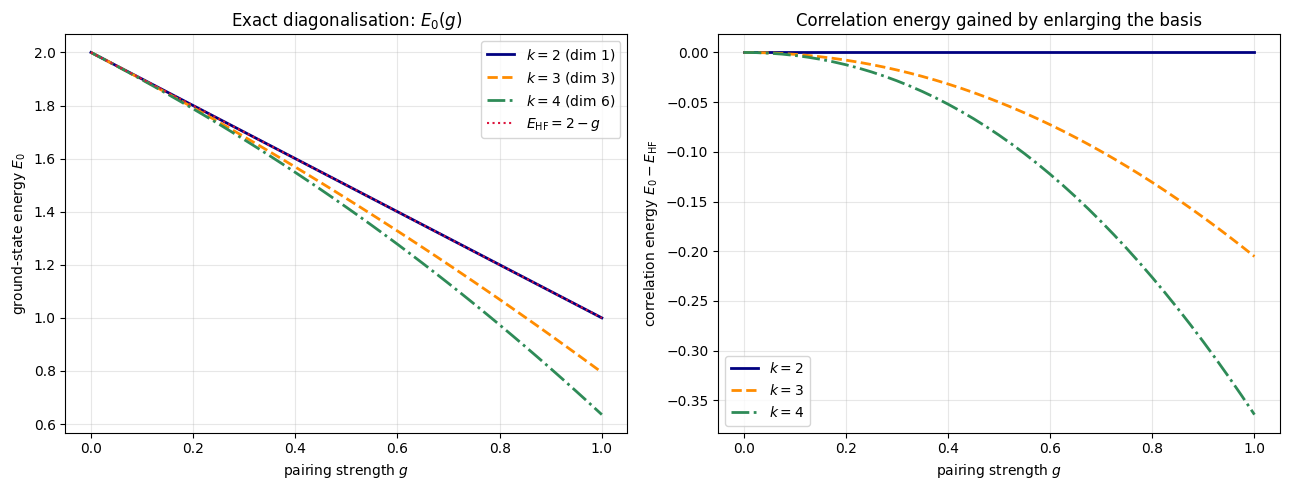

In [4]:
# Correlation energy vs g (exact), the analogue of the week47 plot, for k=2,3,4 (N=4)
g_vals = np.linspace(0.0, 1.0, 41)
E0_exact = {k: np.array([np.linalg.eigvalsh(pairing_seniority0_H(k, g, 4)[0])[0] for g in g_vals])
            for k in (2,3,4)}
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
styles = {2:('navy','-'), 3:('darkorange','--'), 4:('seagreen','-.')}
for k,(c,ls) in styles.items():
    axA.plot(g_vals, E0_exact[k], color=c, ls=ls, lw=2,
             label=f'$k={k}$ (dim {len(list(combinations(range(k),2)))})')
axA.plot(g_vals, E_HF(4, g_vals), color='crimson', ls=':', lw=1.5, label=r'$E_{\rm HF}=2-g$')
axA.set_xlabel('pairing strength $g$'); axA.set_ylabel(r'ground-state energy $E_0$')
axA.set_title('Exact diagonalisation: $E_0(g)$'); axA.legend(); axA.grid(alpha=0.3)
for k,(c,ls) in styles.items():
    axB.plot(g_vals, E0_exact[k]-E_HF(4, g_vals), color=c, ls=ls, lw=2, label=f'$k={k}$')
axB.set_xlabel('pairing strength $g$'); axB.set_ylabel(r'correlation energy $E_0-E_{\rm HF}$')
axB.set_title('Correlation energy gained by enlarging the basis'); axB.legend(); axB.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Full FCI in the $N$-particle sector — and why it equals the seniority-zero result

Building $\hat H$ as a sparse matrix in the Fock basis lets us diagonalise the *full*
$N$-particle problem (all determinants, broken pairs included) and reach large $k$.  The
ground state has no broken pairs, so this **full FCI coincides with the seniority-zero
result** — we verify it for $k=2,\dots,8$, and also check the explicit dense
Jordan–Wigner Hamiltonian for the small cases.

In [5]:
def H_pairing_sparse(k, g, N, states, index, delta=DELTA):
    """Pairing Hamiltonian as a sparse matrix in the N-particle sector (bitstring action)."""
    nq = 2*k; M = len(states); gh = -0.5*g
    rows, cols, vals = [], [], []
    for I in states:
        a = index[I]; rows.append(a); cols.append(a)
        vals.append(sum(delta*(j//2) for j in range(nq) if _bit(I, j, nq)))     # one-body
        for p in range(k):                                                      # -g/2 A_p^dag A_q
            for q in range(k):
                r0, r1 = 2*q, 2*q+1; c0, c1 = 2*p, 2*p+1
                if not _bit(I, r0, nq): continue
                s1 = _jw_sign(I, r0, nq); t = _flip(I, r0, nq)
                if not _bit(t, r1, nq): continue
                s2 = _jw_sign(t, r1, nq); t = _flip(t, r1, nq)
                if _bit(t, c1, nq): continue
                s3 = _jw_sign(t, c1, nq); t = _flip(t, c1, nq)
                if _bit(t, c0, nq): continue
                s4 = _jw_sign(t, c0, nq); J = _flip(t, c0, nq)
                rows.append(index[J]); cols.append(a); vals.append(gh*s1*s2*s3*s4)
    H = csr_matrix((vals, (rows, cols)), shape=(M, M))
    return (H + H.T)*0.5

def fci_ground(H):
    M = H.shape[0]
    if M == 1:    return float(H[0, 0])
    if M <= 1500: return float(np.linalg.eigvalsh(H.toarray())[0])
    return float(eigsh(H, k=1, which='SA', maxiter=5000)[0][0])

def dense_jw_fci(k, g, N):
    """Explicit dense 2^(2k) Jordan-Wigner Hamiltonian; FCI in the N-sector (small k only)."""
    nq, dim = 2*k, 2**(2*k)
    Hk = sum(DELTA*(so//2)*number_op(so, nq) for so in range(nq))
    W = sum(jw_create(2*p,nq)@jw_create(2*p+1,nq)@jw_annihilate(2*q+1,nq)@jw_annihilate(2*q,nq)
            for p in range(k) for q in range(k))
    H = np.real(Hk - 0.5*g*W); H = (H+H.T)/2
    occ = [sum(1<<(nq-1-j) for j in c) for c in combinations(range(nq), N)]
    return np.linalg.eigvalsh(H[np.ix_(occ, occ)])[0]

print("Full FCI (N=4) : sparse N-sector vs seniority-zero vs dense Jordan-Wigner")
print("="*72)
for k in (2,3,4,5,6,7,8):
    nq, states, index = build_sector(k, 4)
    e_fci = fci_ground(H_pairing_sparse(k, 1.0, 4, states, index))
    e_sen = np.linalg.eigvalsh(pairing_seniority0_H(k, 1.0, 4)[0])[0]
    extra = f"  E_denseJW={dense_jw_fci(k,1.0,4):+.6f}" if k <= 4 else ""
    print(f"  k={k}: dim(N=4)={len(states):5d}  E_FCI={e_fci:+.6f}  E_sen0={e_sen:+.6f}"
          f"  diff={e_fci-e_sen:+.1e}{extra}")

Full FCI (N=4) : sparse N-sector vs seniority-zero vs dense Jordan-Wigner
  k=2: dim(N=4)=    1  E_FCI=+1.000000  E_sen0=+1.000000  diff=+0.0e+00  E_denseJW=+1.000000
  k=3: dim(N=4)=   15  E_FCI=+0.794697  E_sen0=+0.794697  diff=+4.4e-16  E_denseJW=+0.794697


  k=4: dim(N=4)=   70  E_FCI=+0.635548  E_sen0=+0.635548  diff=+8.4e-15  E_denseJW=+0.635548
  k=5: dim(N=4)=  210  E_FCI=+0.497768  E_sen0=+0.497768  diff=-2.6e-15
  k=6: dim(N=4)=  495  E_FCI=+0.372664  E_sen0=+0.372664  diff=-2.1e-14
  k=7: dim(N=4)= 1001  E_FCI=+0.256052  E_sen0=+0.256052  diff=+9.0e-15


  k=8: dim(N=4)= 1820  E_FCI=+0.145559  E_sen0=+0.145559  diff=-1.8e-15


All three constructions agree.  The dense Jordan–Wigner matrix is transparent but
costs $2^{2k}$; from here on the sparse fixed-$N$ representation does the heavy lifting,
which is what makes $k=8$ feasible.

---
## 4  Classical coupled-cluster doubles (CCD)

`week47.ipynb` solves the pairing problem with the classical **coupled-cluster doubles**
equations of *LNP 936*, Chapter 8.  Singles vanish identically for the pairing force in a
Hartree–Fock basis (Section 5), so CCD already carries the full singles-and-doubles
content.  We keep that solver and generalise the hole/particle counts to any $(k,N)$:
holes $=N$, particles $=2k-N$ (for $k$ with $2k>N$).  CCD is non-variational and provides
the second comparison curve.

In [6]:
def init_pairing_v(g, pnum, hnum):
    v_pppp = np.zeros((pnum,)*4); v_pphh = np.zeros((pnum,pnum,hnum,hnum)); v_hhhh = np.zeros((hnum,)*4)
    gv = -0.5*g
    for a in range(0,pnum,2):
        for b in range(0,pnum,2):
            v_pppp[a,a+1,b,b+1]=gv; v_pppp[a+1,a,b,b+1]=-gv; v_pppp[a,a+1,b+1,b]=-gv; v_pppp[a+1,a,b+1,b]=gv
    for a in range(0,pnum,2):
        for i in range(0,hnum,2):
            v_pphh[a,a+1,i,i+1]=gv; v_pphh[a+1,a,i,i+1]=-gv; v_pphh[a,a+1,i+1,i]=-gv; v_pphh[a+1,a,i+1,i]=gv
    for j in range(0,hnum,2):
        for i in range(0,hnum,2):
            v_hhhh[j,j+1,i,i+1]=gv; v_hhhh[j+1,j,i,i+1]=-gv; v_hhhh[j,j+1,i+1,i]=-gv; v_hhhh[j+1,j,i+1,i]=gv
    return v_pppp, v_pphh, v_hhhh

def init_pairing_fock(delta, g, pnum, hnum):
    dv, gv = 0.5*delta, -0.5*g; f_pp = np.zeros((pnum,pnum)); f_hh = np.zeros((hnum,hnum))
    for i in range(0,hnum,2): f_hh[i,i]=dv*i+gv; f_hh[i+1,i+1]=dv*i+gv
    for a in range(0,pnum,2): f_pp[a,a]=dv*(hnum+a); f_pp[a+1,a+1]=dv*(hnum+a)
    return f_pp, f_hh

def _t2_den(f_pp, f_hh, t):
    pn, hn = len(f_pp), len(f_hh); out = np.zeros_like(t)
    for i in range(hn):
        for j in range(hn):
            for a in range(pn):
                for b in range(pn):
                    out[a,b,i,j] = t[a,b,i,j]/(f_hh[i,i]+f_hh[j,j]-f_pp[a,a]-f_pp[b,b])
    return out

def ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2):
    Hb = ( v_pphh + np.einsum('bc,acij->abij',f_pp,t2) - np.einsum('ac,bcij->abij',f_pp,t2)
         - np.einsum('abik,kj->abij',t2,f_hh) + np.einsum('abjk,ki->abij',t2,f_hh)
         + 0.5*np.einsum('abcd,cdij->abij',v_pppp,t2) + 0.5*np.einsum('abkl,klij->abij',t2,v_hhhh) )
    chh = 0.5*np.einsum('cdkl,cdjl->kj',v_pphh,t2)
    Hb -= (np.einsum('abik,kj->abij',t2,chh) - np.einsum('abik,kj->abji',t2,chh))
    cpp = -0.5*np.einsum('cdkl,bdkl->cb',v_pphh,t2)
    Hb += (np.einsum('acij,cb->abij',t2,cpp) - np.einsum('acij,cb->baij',t2,cpp))
    chhhh = 0.5*np.einsum('cdkl,cdij->klij',v_pphh,t2)
    Hb += 0.5*np.einsum('abkl,klij->abij',t2,chhhh)
    cphph = 0.5*np.einsum('cdkl,dblj->bkcj',v_pphh,t2)
    Hb += ( np.einsum('bkcj,acik->abij',cphph,t2) - np.einsum('bkcj,acik->baij',cphph,t2)
          - np.einsum('bkcj,acik->abji',cphph,t2) + np.einsum('bkcj,acik->baji',cphph,t2) )
    return t2 + _t2_den(f_pp, f_hh, Hb)

def run_ccd(k, g, N, delta=DELTA, niter=300, mix=0.5, tol=1e-13):
    """Total CCD energy and correlation energy for the pairing model."""
    hnum, pnum = N, 2*k-N; Eref = E_HF(N, g, delta)
    if pnum == 0: return Eref, 0.0
    v_pppp, v_pphh, v_hhhh = init_pairing_v(g, pnum, hnum)
    f_pp, f_hh = init_pairing_fock(delta, g, pnum, hnum)
    t2 = _t2_den(f_pp, f_hh, v_pphh.copy()); erg = 0.25*np.einsum('abij,abij',v_pphh,t2)
    for _ in range(niter):
        t2n = ccd_iter(v_pppp, v_pphh, v_hhhh, f_pp, f_hh, t2)
        ergn = 0.25*np.einsum('abij,abij',v_pphh,t2n); t2 = mix*t2n + (1-mix)*t2
        if abs(ergn-erg) < tol: erg = ergn; break
        erg = ergn
    return Eref + erg, erg

print("Coupled-cluster doubles (CCD) vs exact diagonalisation,  g = 1, N = 4")
print("="*64)
for k in (2,3,4):
    Etot, Ecorr = run_ccd(k, 1.0, 4); E0 = exact_g1[k][0]
    print(f"  k={k}:  E_CCD={Etot:+.6f} (corr {Ecorr:+.6f})   E_exact={E0:+.6f}   diff={Etot-E0:+.2e}")

Coupled-cluster doubles (CCD) vs exact diagonalisation,  g = 1, N = 4
  k=2:  E_CCD=+1.000000 (corr +0.000000)   E_exact=+1.000000   diff=+0.00e+00
  k=3:  E_CCD=+0.794697 (corr -0.205303)   E_exact=+0.794697   diff=+1.42e-13
  k=4:  E_CCD=+0.630443 (corr -0.369557)   E_exact=+0.635548   diff=-5.11e-03


---
## 5  UCCSD ansatz and the variational quantum eigensolver — with Trotterisation

The trial state is the **unitary coupled-cluster singles-and-doubles** wavefunction,
written as a *product* of elementary unitaries built from number-conserving fermionic
excitation generators $\hat\tau_\mu-\hat\tau_\mu^{\dagger}$ acting on the Hartree–Fock
reference:

$$
|\Psi(\boldsymbol\theta)\rangle=
\Big[\prod_{\mu\in\rm D}e^{\theta_\mu(\hat\tau_\mu-\hat\tau_\mu^{\dagger})}\Big]
\Big[\prod_{\nu\in\rm S}e^{\theta_\nu(\hat\tau_\nu-\hat\tau_\nu^{\dagger})}\Big]
|\Phi_{\rm HF}\rangle ,
$$

* **singles** $\hat\tau^{a}_{i}=\hat a^{\dagger}_a\hat a_i$ (spin conserving),
* **doubles** $\hat\tau^{ab}_{ij}=\hat a^{\dagger}_a\hat a^{\dagger}_b\hat a_j\hat a_i$
  ($N$- and $S_z$-conserving), $i<j$ occupied, $a<b$ virtual.

Writing the exponential of the *sum* of generators as a *product* of single-generator
exponentials is exactly **first-order Trotterisation** — and it is how the ansatz is
applied on a quantum computer, one excitation unitary at a time.

**Each factor is a set of disjoint $2\times2$ rotations.**  A single generator
$\hat\tau-\hat\tau^{\dagger}$ couples the Fock-basis determinants in disjoint pairs
$\{|I\rangle,|J\rangle\}$, and $e^{\theta(\hat\tau-\hat\tau^{\dagger})}$ acts on each pair
as the plane rotation $\big(\begin{smallmatrix}\cos\theta&-s\sin\theta\\
s\sin\theta&\cos\theta\end{smallmatrix}\big)$, $s=\pm1$ (equivalently the closed form
$e^{\theta\hat\tau}=1+\sin\theta\,\hat\tau+(1-\cos\theta)\,\hat\tau^{2}$, since
$\hat\tau^{3}=-\hat\tau$).  We precompute the $(I,J,s)$ tables once; one factor then costs
$\mathcal{O}(\#\text{pairs})$ with **no matrix exponential and no $2^{2k}$ Hamiltonian** —
this is what carries the method to $k=8$.

**Particle number.**  Every UCCSD generator conserves $\hat N$, so starting from
$|\Phi_{\rm HF}\rangle$ the state never leaves the $N$-particle sector; no number penalty
is needed (the energy below is the physical energy).

**Singles vanish.**  The pairing force connects only seniority-zero pair configurations,
so the singles amplitudes optimise to zero — exactly why the classical theory is a
*doubles* (CCD) theory.  We keep singles so the ansatz is genuinely UCCSD.

### Gradient: why the naive two-term shift is not enough

For the **first** factor acting on the single determinant $|\Phi_{\rm HF}\rangle$ the
energy is a pure frequency-2 function of that angle, and the two-term shift
$\partial_\theta E=E(\theta+\tfrac{\pi}{4})-E(\theta-\tfrac{\pi}{4})$ is exact.  For
**later** factors the angle acts on an already-correlated state with support both inside
and outside the rotated blocks; the static$\times$rotating cross-terms add a
**frequency-1** piece, so $E(\theta)=a+b\cos\theta+c\sin\theta+d\cos2\theta+e\sin2\theta$
and the two-term shift is incomplete — on hardware one uses the generalised (four-term)
parameter-shift rule.  In this state-vector simulation we evaluate the **exact gradient of
the Trotterised product** (equal to the generalised parameter-shift result) and verify it
against finite differences.

In [7]:
def uccsd_pool(k, N):
    nq = 2*k; occ = list(range(N)); virt = list(range(N, nq))
    singles = [(i, a) for i in occ for a in virt if (i % 2) == (a % 2)]
    doubles = [(i, j, a, b) for (i, j) in combinations(occ, 2)
               for (a, b) in combinations(virt, 2) if (i % 2)+(j % 2) == (a % 2)+(b % 2)]
    return singles, doubles

print("UCCSD pool size vs k  (N = 4)")
print(f"  {'k':>2} {'qubits':>7} {'singles':>8} {'doubles':>8} {'total':>7}")
for k in (2,3,4,5,6,7,8):
    s, d = uccsd_pool(k, 4)
    print(f"  {k:>2} {2*k:>7} {len(s):>8} {len(d):>8} {len(s)+len(d):>7}")

UCCSD pool size vs k  (N = 4)
   k  qubits  singles  doubles   total
   2       4        0        0       0
   3       6        4        4       8
   4       8        8       18      26
   5      10       12       42      54
   6      12       16       76      92
   7      14       20      120     140
   8      16       24      174     198


In [8]:
def exc_single(i, a, nq, states, index):
    Is, Js, sg = [], [], []
    for I in states:
        if not _bit(I, i, nq) or _bit(I, a, nq): continue
        s1 = _jw_sign(I, i, nq); t = _flip(I, i, nq)
        s2 = _jw_sign(t, a, nq); J = _flip(t, a, nq)
        Is.append(index[I]); Js.append(index[J]); sg.append(s1*s2)
    return (np.array(Is), np.array(Js), np.array(sg, float))

def exc_double(i, j, a, b, nq, states, index):
    Is, Js, sg = [], [], []
    for I in states:
        if not _bit(I, i, nq): continue
        s1 = _jw_sign(I, i, nq); t = _flip(I, i, nq)
        if not _bit(t, j, nq): continue
        s2 = _jw_sign(t, j, nq); t = _flip(t, j, nq)
        if _bit(t, b, nq): continue
        s3 = _jw_sign(t, b, nq); t = _flip(t, b, nq)
        if _bit(t, a, nq): continue
        s4 = _jw_sign(t, a, nq); J = _flip(t, a, nq)
        Is.append(index[I]); Js.append(index[J]); sg.append(s1*s2*s3*s4)
    return (np.array(Is), np.array(Js), np.array(sg, float))

def apply_exc(psi, theta, arr):
    """In-place exp(theta*(tau-tau_dag))|psi> via disjoint 2x2 plane rotations."""
    Is, Js, sg = arr
    if Is.size == 0: return
    c, s = np.cos(theta), np.sin(theta)
    a = psi[Is].copy(); b = psi[Js].copy()
    psi[Is] = c*a - sg*s*b; psi[Js] = sg*s*a + c*b

def tau_apply(psi, arr):
    """(tau - tau_dag)|psi>, used for the exact gradient."""
    Is, Js, sg = arr; out = np.zeros_like(psi)
    if Is.size: out[Is] = -sg*psi[Js]; out[Js] = sg*psi[Is]
    return out

def setup_uccsd(k, N):
    nq, states, index = build_sector(k, N)
    singles, doubles = uccsd_pool(k, N)
    arrs = ([exc_single(i, a, nq, states, index) for (i, a) in singles]
            + [exc_double(i, j, a, b, nq, states, index) for (i, j, a, b) in doubles])
    hf = index[sum(1 << (nq-1-j) for j in range(N))]
    return dict(nq=nq, states=states, index=index, singles=singles, doubles=doubles,
                arrs=arrs, nS=len(singles), P=len(arrs), M=len(states), hf=hf)

def uccsd_vqe(setup, H, n_trotter=1, x0=None, tol=(1e-14, 1e-12), maxiter=3000):
    """Trotterised UCCSD-VQE: forward = product of 2x2-block rotations; exact gradient."""
    arrs = setup['arrs']; P = setup['P']; M = setup['M']; hf = setup['hf']
    seq = list(range(P))*n_trotter; S = len(seq)
    def energy0():
        psi = np.zeros(M); psi[hf] = 1.0; return float(psi @ (H @ psi))
    if P == 0:
        return energy0(), np.zeros(0), (lambda p: energy0()), (lambda p: np.zeros(0))
    def energy(p):
        psi = np.zeros(M); psi[hf] = 1.0
        for kk in seq: apply_exc(psi, p[kk]/n_trotter, arrs[kk])
        return float(psi @ (H @ psi))
    def grad(p):
        psi = np.zeros(M); psi[hf] = 1.0; st = [psi.copy()]
        for kk in seq: apply_exc(psi, p[kk]/n_trotter, arrs[kk]); st.append(psi.copy())
        Hpsi = H @ st[-1]; gstep = np.zeros(S)
        for step in range(S):
            kk = seq[step]; v = tau_apply(st[step+1], arrs[kk])
            for s2 in range(step+1, S): apply_exc(v, p[seq[s2]]/n_trotter, arrs[seq[s2]])
            gstep[step] = 2.0*float(v @ Hpsi)
        g = np.zeros(P)
        for step in range(S): g[seq[step]] += gstep[step]/n_trotter
        return g
    if x0 is None: x0 = np.zeros(P)
    res = minimize(energy, x0, jac=grad, method='L-BFGS-B',
                   options={'ftol': tol[0], 'gtol': tol[1], 'maxiter': maxiter})
    return res.fun, res.x, energy, grad

# --- verify the exact product gradient against finite differences (k = 6, N = 4) ---
su = setup_uccsd(6, 4)
Hck = H_pairing_sparse(6, 1.0, 4, *build_sector(6, 4)[1:])
_, _, en, gr = uccsd_vqe(su, Hck)
rng = np.random.default_rng(0); p = rng.uniform(-0.2, 0.2, su['P'])
ga = gr(p); eye = np.eye(su['P'])
gf = np.array([(en(p+1e-6*eye[i]) - en(p-1e-6*eye[i]))/2e-6 for i in range(su['P'])])
print(f"exact UCCSD gradient vs finite differences (k=6, N=4): max |diff| = {np.max(np.abs(ga-gf)):.2e}")

exact UCCSD gradient vs finite differences (k=6, N=4): max |diff| = 3.60e-09


---
## 6  Three-method comparison at $k=2,3,4$

We first reproduce the pedagogical case: $N=4$ fermions in $k=2,3,4$ levels, comparing
exact diagonalisation, CCD, and the Trotterised UCCSD–VQE, both at $g=1$ and across the
full sweep $g\in[0,1]$.

In [9]:
print("UCCSD-VQE at g = 1   (N = 4, HF reference, started from theta = 0)")
print("="*72)
vqe_g1 = {}
for k in (2,3,4):
    su = setup_uccsd(k, 4); H = H_pairing_sparse(k, 1.0, 4, su['states'], su['index'])
    t0 = time.time(); E_vqe, theta, _, _ = uccsd_vqe(su, H)
    vqe_g1[k] = E_vqe; E0 = exact_g1[k][0]; Ecc = run_ccd(k, 1.0, 4)[0]
    smax = max([abs(t) for t,lab in zip(theta, su['singles']+[None]*len(su['doubles'])) if lab is not None], default=0.0)
    print(f"  k={k}:  E_UCCSD={E_vqe:+.6f}   E_CCD={Ecc:+.6f}   E_exact={E0:+.6f}")
    print(f"         UCCSD-exact={E_vqe-E0:+.2e} (>=0, variational)   CCD-exact={Ecc-E0:+.2e}"
          f"   max|theta_S|={smax:.1e}   ({time.time()-t0:.1f}s)")
print("\nEvery singles amplitude is zero to machine precision -- the pairing force does not")
print("couple to single (seniority-changing) excitations, hence a *doubles* classical theory.")

UCCSD-VQE at g = 1   (N = 4, HF reference, started from theta = 0)
  k=2:  E_UCCSD=+1.000000   E_CCD=+1.000000   E_exact=+1.000000
         UCCSD-exact=+0.00e+00 (>=0, variational)   CCD-exact=+0.00e+00   max|theta_S|=0.0e+00   (0.0s)
  k=3:  E_UCCSD=+0.794697   E_CCD=+0.794697   E_exact=+0.794697
         UCCSD-exact=+1.11e-16 (>=0, variational)   CCD-exact=+1.42e-13   max|theta_S|=0.0e+00   (0.0s)
  k=4:  E_UCCSD=+0.636987   E_CCD=+0.630443   E_exact=+0.635548
         UCCSD-exact=+1.44e-03 (>=0, variational)   CCD-exact=-5.11e-03   max|theta_S|=0.0e+00   (0.1s)

Every singles amplitude is zero to machine precision -- the pairing force does not
couple to single (seniority-changing) excitations, hence a *doubles* classical theory.


g-sweep (k=2,3,4) finished in 1.7 s


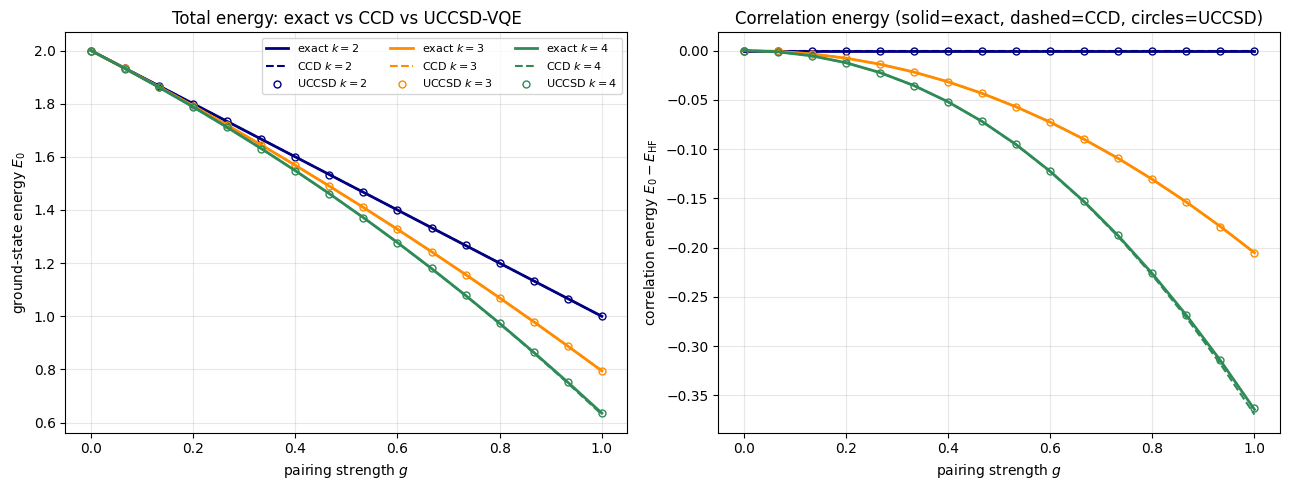

CCD is exact for k=2,3 and slightly over-binds at k=4; UCCSD-VQE is exact for
k=2,3 and a tight variational upper bound at k=4 -- the three curves nearly overlap.


In [10]:
# Sweep g for the three methods at k = 2, 3, 4 (N = 4)
g_scan = np.linspace(0.0, 1.0, 16)
E_ex = {k: [] for k in (2,3,4)}; E_cc = {k: [] for k in (2,3,4)}; E_vq = {k: [] for k in (2,3,4)}
setups = {k: setup_uccsd(k, 4) for k in (2,3,4)}
t0 = time.time()
for k in (2,3,4):
    su = setups[k]
    for g in g_scan:
        E_ex[k].append(np.linalg.eigvalsh(pairing_seniority0_H(k, g, 4)[0])[0])
        E_cc[k].append(run_ccd(k, g, 4)[0])
        E_vq[k].append(uccsd_vqe(su, H_pairing_sparse(k, g, 4, su['states'], su['index']))[0])
    E_ex[k]=np.array(E_ex[k]); E_cc[k]=np.array(E_cc[k]); E_vq[k]=np.array(E_vq[k])
print(f"g-sweep (k=2,3,4) finished in {time.time()-t0:.1f} s")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
colors = {2:'navy', 3:'darkorange', 4:'seagreen'}
for k in (2,3,4):
    c = colors[k]
    axL.plot(g_scan, E_ex[k], '-',  color=c, lw=2,             label=f'exact $k={k}$')
    axL.plot(g_scan, E_cc[k], '--', color=c, lw=1.5,           label=f'CCD $k={k}$')
    axL.plot(g_scan, E_vq[k], 'o',  color=c, ms=5, mfc='none', label=f'UCCSD $k={k}$')
axL.set_xlabel('pairing strength $g$'); axL.set_ylabel('ground-state energy $E_0$')
axL.set_title('Total energy: exact vs CCD vs UCCSD-VQE'); axL.legend(ncol=3, fontsize=8); axL.grid(alpha=0.3)
for k in (2,3,4):
    c = colors[k]
    axR.plot(g_scan, E_ex[k]-E_HF(4, g_scan), '-',  color=c, lw=2)
    axR.plot(g_scan, E_cc[k]-E_HF(4, g_scan), '--', color=c, lw=1.5)
    axR.plot(g_scan, E_vq[k]-E_HF(4, g_scan), 'o',  color=c, ms=5, mfc='none')
axR.set_xlabel('pairing strength $g$'); axR.set_ylabel(r'correlation energy $E_0-E_{\rm HF}$')
axR.set_title('Correlation energy (solid=exact, dashed=CCD, circles=UCCSD)'); axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("CCD is exact for k=2,3 and slightly over-binds at k=4; UCCSD-VQE is exact for")
print("k=2,3 and a tight variational upper bound at k=4 -- the three curves nearly overlap.")

---
## 7  Scaling to $k=8$ with Trotterised UCCSD

Because the Trotterised ansatz never forms a dense operator, the *same* solver runs far
beyond the pedagogical sizes.  Keeping $N=4$, we scan $k=2,\dots,8$; at $k=8$ this is a
16-qubit problem solved inside the $\binom{16}{4}=1820$-dimensional sector.

 k qubits  dimFCI        FCI        CCD      UCCSD     U-FCI   CCD-FCI  #par
------------------------------------------------------------------------------------
 2      4       1   1.000000   1.000000   1.000000  +0.0e+00  +0.0e+00     0
 3      6      15   0.794697   0.794697   0.794697  -3.3e-16  +1.4e-13     8
 4      8      70   0.635548   0.630443   0.636987  +1.4e-03  -5.1e-03    26


 5     10     210   0.497768   0.484977   0.501278  +3.5e-03  -1.3e-02    54


 6     12     495   0.372664   0.350058   0.378719  +6.1e-03  -2.3e-02    92


 7     14    1001   0.256052   0.221608   0.265052  +9.0e-03  -3.4e-02   140


 8     16    1820   0.145559   0.097263   0.157856  +1.2e-02  -4.8e-02   198

UCCSD stays variational (>= FCI); CCD over-binds (< FCI).


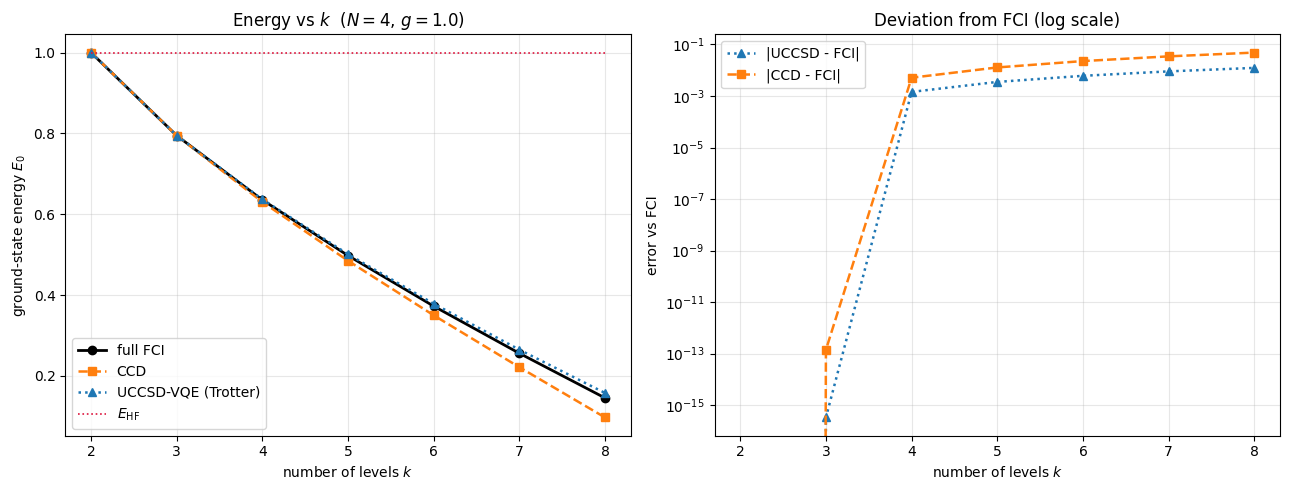

At k=8 (16 qubits): UCCSD-FCI = +1.23e-02,  CCD-FCI = -4.83e-02


In [11]:
N = 4; g = 1.0; ks = [2,3,4,5,6,7,8]; rows = []
print(f"{'k':>2} {'qubits':>6} {'dimFCI':>7} {'FCI':>10} {'CCD':>10} {'UCCSD':>10} "
      f"{'U-FCI':>9} {'CCD-FCI':>9} {'#par':>5}")
print("-"*84)
for k in ks:
    su = setup_uccsd(k, N); H = H_pairing_sparse(k, g, N, su['states'], su['index'])
    e_fci = fci_ground(H); e_ccd, _ = run_ccd(k, g, N); e_u, _, _, _ = uccsd_vqe(su, H)
    rows.append((k, 2*k, su['M'], e_fci, e_ccd, e_u, su['P']))
    print(f"{k:>2} {2*k:>6} {su['M']:>7} {e_fci:>10.6f} {e_ccd:>10.6f} {e_u:>10.6f} "
          f"{e_u-e_fci:>+9.1e} {e_ccd-e_fci:>+9.1e} {su['P']:>5}")
print("\nUCCSD stays variational (>= FCI); CCD over-binds (< FCI).")

ks_a=np.array([r[0] for r in rows]); e_fci_a=np.array([r[3] for r in rows])
e_ccd_a=np.array([r[4] for r in rows]); e_u_a=np.array([r[5] for r in rows])
fig,(axL,axR)=plt.subplots(1,2,figsize=(13,5))
axL.plot(ks_a,e_fci_a,'k-o',lw=2,label='full FCI')
axL.plot(ks_a,e_ccd_a,'C1--s',lw=1.8,label='CCD')
axL.plot(ks_a,e_u_a,'C0:^',lw=1.8,label='UCCSD-VQE (Trotter)')
axL.plot(ks_a,[E_HF(N,g)]*len(ks_a),color='crimson',ls=':',lw=1.2,label=r'$E_{\rm HF}$')
axL.set_xlabel('number of levels $k$'); axL.set_ylabel('ground-state energy $E_0$')
axL.set_title(f'Energy vs $k$  ($N={N}$, $g={g}$)'); axL.legend(); axL.grid(alpha=0.3)
axR.semilogy(ks_a,np.abs(e_u_a-e_fci_a),'C0:^',lw=1.8,label='|UCCSD - FCI|')
axR.semilogy(ks_a,np.abs(e_ccd_a-e_fci_a),'C1--s',lw=1.8,label='|CCD - FCI|')
axR.set_xlabel('number of levels $k$'); axR.set_ylabel('error vs FCI')
axR.set_title('Deviation from FCI (log scale)'); axR.legend(); axR.grid(alpha=0.3,which='both')
plt.tight_layout(); plt.show()
print(f"At k=8 (16 qubits): UCCSD-FCI = {e_u_a[-1]-e_fci_a[-1]:+.2e},  CCD-FCI = {e_ccd_a[-1]-e_fci_a[-1]:+.2e}")

Both correlated methods recover most of the correlation energy.  UCCSD remains a
variational upper bound whose error grows slowly with $k$ (from $\sim\!10^{-3}$ at $k=4$
to $\sim\!10^{-2}$ at $k=8$), while CCD over-binds with a larger-magnitude error.

---
## 8  Effect of the number of Trotter steps

The product ansatz is *first-order* Trotter.  Repeating the product $n_{\rm Trotter}$
times (each angle rescaled by $1/n_{\rm Trotter}$ and re-optimised) tests whether the
Trotter splitting itself limits accuracy.

In [12]:
k_t, N_t = 6, 4
su_t = setup_uccsd(k_t, N_t); H_t = H_pairing_sparse(k_t, 1.0, N_t, su_t['states'], su_t['index'])
e_fci_t = fci_ground(H_t)
print(f"Trotter-step convergence at k={k_t}, N={N_t}, g=1   (FCI = {e_fci_t:.6f})")
print("-"*52)
for nt in (1, 2, 3):
    t0 = time.time(); e_u, _, _, _ = uccsd_vqe(su_t, H_t, n_trotter=nt)
    print(f"  n_Trotter = {nt}:  E_UCCSD = {e_u:.6f}   E-FCI = {e_u-e_fci_t:+.2e}   ({time.time()-t0:.1f}s)")
print("\nThe energy is essentially flat in n_Trotter: first-order Trotter is already converged.")
print("The residual gap to FCI is the singles-and-doubles *truncation* error, not Trotter error.")

Trotter-step convergence at k=6, N=4, g=1   (FCI = 0.372664)
----------------------------------------------------


  n_Trotter = 1:  E_UCCSD = 0.378719   E-FCI = +6.06e-03   (0.6s)


  n_Trotter = 2:  E_UCCSD = 0.378797   E-FCI = +6.13e-03   (2.1s)


  n_Trotter = 3:  E_UCCSD = 0.378795   E-FCI = +6.13e-03   (4.9s)

The energy is essentially flat in n_Trotter: first-order Trotter is already converged.
The residual gap to FCI is the singles-and-doubles *truncation* error, not Trotter error.


---
## 9  Varying the number of particles

Nothing is tied to $N=4$.  Fixing $k=6$, we sweep the (even) particle number
$N=2,4,6,8$ and compare UCCSD–VQE with full FCI and CCD.

In [13]:
k_v = 6
print(f"Varying N at k={k_v}, g=1")
print(f"  {'N':>2} {'pairs':>5} {'dimFCI':>7} {'FCI':>11} {'CCD':>11} {'UCCSD':>11} {'U-FCI':>9}")
print("  " + "-"*64)
for N_v in (2, 4, 6, 8):
    su = setup_uccsd(k_v, N_v); H_v = H_pairing_sparse(k_v, 1.0, N_v, su['states'], su['index'])
    e_fci = fci_ground(H_v); e_ccd, _ = run_ccd(k_v, 1.0, N_v); e_u, _, _, _ = uccsd_vqe(su, H_v)
    print(f"  {N_v:>2} {N_v//2:>5} {su['M']:>7} {e_fci:>11.6f} {e_ccd:>11.6f} {e_u:>11.6f} {e_u-e_fci:>+9.1e}")
print("\nN=2 (one pair) is reproduced exactly; for N>=4 UCCSD is a tight variational bound.")

Varying N at k=6, g=1
   N pairs  dimFCI         FCI         CCD       UCCSD     U-FCI
  ----------------------------------------------------------------


   2     1      66   -0.906337   -0.906337   -0.906337  -1.6e-15


   4     2     495    0.372664    0.350058    0.378719  +6.1e-03


   6     3     924    3.801528    3.768061    3.809807  +8.3e-03


   8     4     495    9.372664    9.350058    9.378308  +5.6e-03

N=2 (one pair) is reproduced exactly; for N>=4 UCCSD is a tight variational bound.


---
## 10  Gate-based VQE: implementing the ansatz as a quantum circuit

Sections 1–9 evaluated the UCCSD ansatz by acting with operators on the state vector.  We
now implement the VQE **the way it runs on a quantum computer**: the trial state is
prepared by an explicit circuit of single-qubit **rotation gates** (variational angles on
the Bloch sphere) and two-qubit **CNOT** entanglers, and the energy is the expectation
value of that prepared state.  Two circuit ansätze are built and compared with the
references already established above:

1. **Hardware-efficient ansatz (HEA)** — layers of $R_y(\theta)$ rotations interleaved
   with CNOT entanglers (as in the `qdresrefinement` $K=2/K=6$ circuits).  It has no
   built-in particle-number symmetry, so a number penalty is added and gradients use the
   two-term $\pi/2$ parameter-shift rule (exact for $R_y$).
2. **Gate-level UCCSD** — the *same* unitary coupled-cluster ansatz of Section 5, but each
   Trotter factor $e^{\theta(\hat\tau-\hat\tau^{\dagger})}$ is now compiled, through the
   Jordan–Wigner map, into native gates: a basis change + **CNOT ladder** + $R_z(\theta)$
   + uncompute.

We reuse the exact-diagonalisation, CCD and (operator-level) UCCSD solvers built above as
the benchmark, for $k=2,3,4$ at $N=4$.

In [14]:
from scipy.linalg import expm   # only new import needed for the gate chapter

# Recall the references for k = 2,3,4 (reusing the solvers defined earlier in this notebook)
REF = {}
for k in (2, 3, 4):
    su = setup_uccsd(k, 4)
    H  = H_pairing_sparse(k, 1.0, 4, su['states'], su['index'])
    REF[k] = dict(fci=fci_ground(H), ccd=run_ccd(k, 1.0, 4)[0], sv=uccsd_vqe(su, H)[0])
print("Reference energies (N=4, g=1), from the solvers of Sections 3-5")
print(f"  {'k':>2} {'FCI':>11} {'CCD':>11} {'UCCSD(sv)':>11}")
for k in (2,3,4):
    print(f"  {k:>2} {REF[k]['fci']:>11.6f} {REF[k]['ccd']:>11.6f} {REF[k]['sv']:>11.6f}")

Reference energies (N=4, g=1), from the solvers of Sections 3-5
   k         FCI         CCD   UCCSD(sv)
   2    1.000000    1.000000    1.000000
   3    0.794697    0.794697    0.794697
   4    0.635548    0.630443    0.636987


### A gate-based state-vector simulator

A quantum computer manipulates the register only through gates.  We model exactly that: a
state $|\psi\rangle\in\mathbb{C}^{2^{n}}$ ($n=2k$ qubits) acted on by single-qubit
rotations such as $R_y(\theta)=e^{-i\theta Y/2}$ and by CNOT (flip the target iff the
control is $|1\rangle$).  Each gate is applied by reshaping the state vector around the
relevant qubit(s) — no full $2^n\times2^n$ matrix is ever formed.

In [15]:
def apply_1q(psi, U, q, n):
    """Apply a single-qubit gate U to qubit q of an n-qubit state vector."""
    psi = psi.reshape((2**q, 2, 2**(n-1-q)))
    return np.einsum('ab,ibj->iaj', U, psi).reshape(-1)

def apply_cnot(psi, c, t, n):
    """Apply CNOT with control c, target t (a genuine 2-qubit entangler)."""
    idx = np.arange(2**n)
    ctrl = ((idx >> (n-1-c)) & 1) == 1
    return psi[np.where(ctrl, idx ^ (1 << (n-1-t)), idx)]

def Ry(th):
    c, s = np.cos(th/2), np.sin(th/2); return np.array([[c,-s],[s,c]], complex)
def Rz(th):
    return np.array([[np.exp(-1j*th/2), 0],[0, np.exp(1j*th/2)]], complex)
Hgate = np.array([[1,1],[1,-1]], complex)/np.sqrt(2)
Sdg = np.array([[1,0],[0,-1j]], complex); Sg = np.array([[1,0],[0,1j]], complex)

# demo: an entangling 2-qubit circuit  Ry(pi/2) on q0, then CNOT(0->1)
psi = np.zeros(4, complex); psi[0] = 1.0
psi = apply_1q(psi, Ry(np.pi/2), 0, 2); psi = apply_cnot(psi, 0, 1, 2)
print("Ry(pi/2) on q0 then CNOT(0->1):")
for b, amp in zip(['00','01','10','11'], psi):
    if abs(amp) > 1e-9: print(f"   |{b}>: {amp.real:+.4f}")

Ry(pi/2) on q0 then CNOT(0->1):
   |00>: +0.7071
   |11>: +0.7071


---
## 11  The Pauli-rotation primitive $e^{-i\frac{\phi}{2}P}$

Both ansätze ultimately apply $e^{-i\frac{\phi}{2}P}$ for a Pauli string
$P=\bigotimes_q\sigma_q$, built the textbook way: basis-change each active qubit into the
$Z$ eigenbasis ($H$ for $X$, $HS^\dagger$ for $Y$), a CNOT ladder accumulating the parity
onto the last active qubit, a single $R_z(\phi)$, then uncompute.  We verify it against
the exact matrix exponential.

In [16]:
def basis_change(psi, pauli, n, inverse=False):
    for q, P in pauli.items():
        if P == 'Z': continue
        U = Hgate if P == 'X' else ((Hgate@Sdg) if not inverse else (Sg@Hgate))
        psi = apply_1q(psi, U, q, n)
    return psi

def pauli_exp(psi, phi, pauli, n):
    """Apply exp(-i phi/2 * P), with P given as {qubit: 'X'/'Y'/'Z'}."""
    qs = sorted(pauli.keys())
    psi = basis_change(psi, pauli, n, inverse=False)
    for a, b in zip(qs[:-1], qs[1:]): psi = apply_cnot(psi, a, b, n)
    psi = apply_1q(psi, Rz(phi), qs[-1], n)
    for a, b in list(zip(qs[:-1], qs[1:]))[::-1]: psi = apply_cnot(psi, a, b, n)
    return basis_change(psi, pauli, n, inverse=True)

def _pmat(pauli, n):                       # dense Pauli string, reusing Section-2 matrices
    Pm = {'I': I2, 'X': X, 'Y': Y, 'Z': Z}
    return kron_n(*[Pm[pauli.get(q, 'I')] for q in range(n)])

rng = np.random.default_rng(0); n = 4; pauli = {1:'Y', 2:'Z', 3:'X'}; phi = 0.7
psi = rng.normal(size=2**n) + 1j*rng.normal(size=2**n); psi /= np.linalg.norm(psi)
err = np.max(np.abs(pauli_exp(psi.copy(), phi, pauli, n) - expm(-1j*phi/2*_pmat(pauli, n))@psi))
print(f"Pauli-rotation circuit vs exp(-i phi/2 P):  max error = {err:.2e}")

Pauli-rotation circuit vs exp(-i phi/2 P):  max error = 3.36e-16


---
## 12  Hardware-efficient ansatz (rotation + CNOT layers)

Starting from the Hartree–Fock register $|1\cdots1\,0\cdots0\rangle$, apply $L$ layers of
an $R_y$ rotation on every qubit followed by a CNOT entangler (nearest-neighbour plus a
wrap-around bond), then a final $R_y$ layer.  Because $R_y$/CNOT do **not** conserve
particle number we minimise $\langle\hat H+\lambda(\hat N-N)^2\rangle$ with the exact
$\pi/2$ parameter-shift gradient, using a two-stage Nelder–Mead $\to$ L-BFGS-B with random
restarts — symmetry-blind circuits have rugged landscapes.

In [17]:
def build_H_full(k, g, delta=DELTA):
    """Pairing H over the FULL 2^(2k) Fock space (the HEA does not conserve N)."""
    nq = 2*k; dim = 2**nq; gh = -0.5*g; rows, cols, vals = [], [], []
    for I in range(dim):
        rows.append(I); cols.append(I)
        vals.append(sum(delta*(j//2) for j in range(nq) if _bit(I, j, nq)))
        for p in range(k):
            for q in range(k):
                r0, r1 = 2*q, 2*q+1; c0, c1 = 2*p, 2*p+1
                if not _bit(I, r0, nq): continue
                s1 = _jw_sign(I, r0, nq); t = _flip(I, r0, nq)
                if not _bit(t, r1, nq): continue
                s2 = _jw_sign(t, r1, nq); t = _flip(t, r1, nq)
                if _bit(t, c1, nq): continue
                s3 = _jw_sign(t, c1, nq); t = _flip(t, c1, nq)
                if _bit(t, c0, nq): continue
                s4 = _jw_sign(t, c0, nq); J = _flip(t, c0, nq)
                rows.append(J); cols.append(I); vals.append(gh*s1*s2*s3*s4)
    H = csr_matrix((vals, (rows, cols)), shape=(dim, dim))
    return ((H + H.T)*0.5).toarray().real

def hea_vqe(k, N, g, n_layers, lam=10.0, n_starts=10, seed=0, delta=DELTA):
    nq = 2*k; dim = 2**nq
    H = build_H_full(k, g, delta)
    Ndiag = np.array([bin(I).count('1') for I in range(dim)], float)
    Heff = H + lam*np.diag((Ndiag - N)**2)
    hf = sum(1 << (nq-1-j) for j in range(N)); nparam = nq*(n_layers+1)
    def state(p):
        psi = np.zeros(dim, complex); psi[hf] = 1.0; idx = 0
        for L in range(n_layers):
            for q in range(nq): psi = apply_1q(psi, Ry(p[idx]), q, nq); idx += 1
            for q in range(0, nq-1, 2): psi = apply_cnot(psi, q, q+1, nq)
            for q in range(1, nq-1, 2): psi = apply_cnot(psi, q, q+1, nq)
            psi = apply_cnot(psi, nq-1, 0, nq)
        for q in range(nq): psi = apply_1q(psi, Ry(p[idx]), q, nq); idx += 1
        return psi
    def en_eff(p): psi = state(p); return float(np.real(psi.conj() @ (Heff @ psi)))
    def en_phys(p): psi = state(p); return float(np.real(psi.conj() @ (H @ psi)))
    def Nexp(p): psi = state(p); return float(np.sum(np.abs(psi)**2 * Ndiag))
    def grad(p):
        g_ = np.zeros(nparam)
        for m in range(nparam):
            pp = p.copy(); pp[m] += np.pi/2; pm = p.copy(); pm[m] -= np.pi/2
            g_[m] = (en_eff(pp) - en_eff(pm))/2
        return g_
    rng = np.random.default_rng(seed); best = None
    for s in range(n_starts):
        p0 = rng.uniform(-np.pi, np.pi, nparam)
        r1 = minimize(en_eff, p0, method='Nelder-Mead', options={'maxiter':300,'fatol':1e-4,'xatol':1e-4})
        r2 = minimize(en_eff, r1.x, jac=grad, method='L-BFGS-B', options={'ftol':1e-12,'gtol':1e-9,'maxiter':400})
        ep = en_phys(r2.x)
        if best is None or ep < best[0]: best = (ep, Nexp(r2.x), nparam)
    return best

print("Hardware-efficient ansatz VQE (Ry + CNOT layers, number penalty)")
print("="*64)
hea_res = {}
for k, L in [(2, 2), (3, 4)]:
    t0 = time.time(); ep, Nx, npar = hea_vqe(k, 4, 1.0, L, n_starts=10)
    hea_res[k] = ep
    print(f"  k={k}, layers={L} ({npar} angles):  E_HEA={ep:.6f}  <N>={Nx:.3f}  "
          f"FCI={REF[k]['fci']:.6f}  diff={ep-REF[k]['fci']:+.2e}  ({time.time()-t0:.1f}s)")

Hardware-efficient ansatz VQE (Ry + CNOT layers, number penalty)


  k=2, layers=2 (12 angles):  E_HEA=1.000000  <N>=4.000  FCI=1.000000  diff=-1.06e-13  (2.7s)


  k=3, layers=4 (30 angles):  E_HEA=0.794697  <N>=4.000  FCI=0.794697  diff=+2.45e-13  (60.4s)


The hardware-efficient ansatz is exact for $k=2$ and reaches FCI for $k=3$ only after
a multi-start, two-stage optimisation.  For $k=4$ (8 qubits) the symmetry-blind landscape
is dominated by local minima and the restart cost grows quickly — the textbook
barren-plateau / local-minimum difficulty that motivates a physically structured ansatz
such as UCCSD.

---
## 13  Gate-level UCCSD

The UCCSD ansatz of Section 5, now compiled into native gates.  Through Jordan–Wigner an
anti-Hermitian excitation generator becomes a sum of **commuting** Pauli strings, so its
exponential factorises into the Pauli-rotation circuits of Section 11:

* a **single** excitation $\hat a^{\dagger}_a\hat a_i-\text{h.c.}$ gives **2** strings
  ($Z$-string between $i$ and $a$, with $X/Y$ on the endpoints) $\Rightarrow$ 2 CNOT
  ladders;
* a **double** excitation gives **8** strings $\Rightarrow$ 8 CNOT ladders.

For each excitation we read off the exact Pauli content from its generator (a one-time
classical derivation of the circuit) and verify the circuit reproduces the exact unitary
$e^{\theta(\hat\tau-\hat\tau^{\dagger})}$.  The generators reuse the dense Jordan–Wigner
operators `jw_create`/`jw_annihilate` of Section 2.

In [18]:
def _between(p, q):
    lo, hi = min(p, q), max(p, q); return list(range(lo+1, hi))

def _terms_from_generator(T, active, zset, n):
    """T = sum_k (1j*b_k) P_k over odd-Y Pauli strings P_k; return [(Pdict, b_k)]."""
    import itertools
    base = {q: 'Z' for q in zset}; terms = []; recon = np.zeros_like(T)
    for pat in itertools.product('XY', repeat=len(active)):
        if pat.count('Y') % 2 == 0: continue
        P = dict(base)
        for q, pa in zip(active, pat): P[q] = pa
        M = _pmat(P, n); coeff = np.trace(T @ M)/(2**n)
        if abs(coeff) > 1e-9:
            terms.append((P, float(np.imag(coeff)))); recon = recon + coeff*M
    assert np.max(np.abs(recon - T)) < 1e-9, "Pauli reconstruction failed"
    return terms

def make_single(i, a, n):
    G = jw_create(a, n) @ jw_annihilate(i, n)
    return _terms_from_generator(G - G.conj().T, [i, a], _between(i, a), n)
def make_double(i, j, a, b, n):
    G = jw_create(a, n) @ jw_create(b, n) @ jw_annihilate(j, n) @ jw_annihilate(i, n)
    return _terms_from_generator(G - G.conj().T, [i, j, a, b],
                                 set(_between(i, j)) | set(_between(a, b)), n)

def apply_exc_circuit(psi, theta, terms, n):
    """exp(theta*(tau - tau_dag)) = product of Pauli-rotation circuits (commuting terms)."""
    for P, bk in terms:
        psi = pauli_exp(psi, -2.0*theta*bk, P, n)
    return psi

rng = np.random.default_rng(3); n = 6
print("Excitation-circuit verification (vs exact matrix exponential)")
print("-"*60)
for (i, a) in [(0, 4), (1, 5), (0, 2)]:
    terms = make_single(i, a, n); th = rng.uniform(-1, 1)
    G = jw_create(a, n) @ jw_annihilate(i, n); T = G - G.conj().T
    psi = rng.normal(size=2**n) + 1j*rng.normal(size=2**n); psi /= np.linalg.norm(psi)
    d = np.max(np.abs(apply_exc_circuit(psi.copy(), th, terms, n) - expm(th*T)@psi))
    print(f"  single {i}->{a}: {len(terms)} Pauli rot, {sum(2*(len(P)-1) for P,_ in terms)} CNOTs, err={d:.1e}")
for (i, j, a, b) in [(0, 1, 4, 5), (0, 2, 4, 5)]:
    terms = make_double(i, j, a, b, n); th = rng.uniform(-1, 1)
    G = jw_create(a, n) @ jw_create(b, n) @ jw_annihilate(j, n) @ jw_annihilate(i, n); T = G - G.conj().T
    psi = rng.normal(size=2**n) + 1j*rng.normal(size=2**n); psi /= np.linalg.norm(psi)
    d = np.max(np.abs(apply_exc_circuit(psi.copy(), th, terms, n) - expm(th*T)@psi))
    print(f"  double {i},{j}->{a},{b}: {len(terms)} Pauli rot, {sum(2*(len(P)-1) for P,_ in terms)} CNOTs, err={d:.1e}")

Excitation-circuit verification (vs exact matrix exponential)
------------------------------------------------------------
  single 0->4: 2 Pauli rot, 16 CNOTs, err=2.2e-16
  single 1->5: 2 Pauli rot, 16 CNOTs, err=2.7e-16
  single 0->2: 2 Pauli rot, 8 CNOTs, err=2.4e-16
  double 0,1->4,5: 8 Pauli rot, 48 CNOTs, err=1.4e-15
  double 0,2->4,5: 8 Pauli rot, 64 CNOTs, err=1.7e-15


### Gate-level UCCSD VQE

The trial state is prepared by applying the singles then the doubles excitation circuits
to the HF register (first-order Trotter, as in Section 5).  The state preparation is a
genuine rotation+CNOT circuit, and we report its gate counts.  The optimiser starts from
$\boldsymbol\theta=0$ and uses the exact ansatz gradient (equivalent to the generalised
parameter-shift rule).

In [19]:
def gate_uccsd_setup(k, N):
    nq = 2*k; singles, doubles = uccsd_pool(k, N)
    terms = [make_single(i, a, nq) for (i, a) in singles] \
          + [make_double(i, j, a, b, nq) for (i, j, a, b) in doubles]
    gens = []
    for (i, a) in singles:
        G = jw_create(a, nq) @ jw_annihilate(i, nq); gens.append(G - G.conj().T)
    for (i, j, a, b) in doubles:
        G = jw_create(a, nq) @ jw_create(b, nq) @ jw_annihilate(j, nq) @ jw_annihilate(i, nq)
        gens.append(G - G.conj().T)
    hf = sum(1 << (nq-1-j) for j in range(N))
    ncnot = sum(2*(len(P)-1) for tm in terms for (P, _) in tm); nrot = sum(len(tm) for tm in terms)
    return dict(nq=nq, terms=terms, gens=gens, hf=hf, P=len(terms), ncnot=ncnot, nrot=nrot)

def gate_uccsd_vqe(k, N, g, setup, delta=DELTA):
    nq = 2*k; dim = 2**nq; terms = setup['terms']; gens = setup['gens']; hf = setup['hf']; P = setup['P']
    H = build_H_full(k, g, delta)
    def state(th):
        psi = np.zeros(dim, complex); psi[hf] = 1.0
        for m in range(P): psi = apply_exc_circuit(psi, th[m], terms[m], nq)
        return psi
    def energy(th): psi = state(th); return float(np.real(psi.conj() @ (H @ psi)))
    def grad(th):
        psi = np.zeros(dim, complex); psi[hf] = 1.0; st = [psi.copy()]
        for m in range(P): psi = apply_exc_circuit(psi, th[m], terms[m], nq); st.append(psi.copy())
        Hpsi = H @ st[P]; gg = np.zeros(P)
        for mu in range(P):
            v = gens[mu] @ st[mu+1]
            for m in range(mu+1, P): v = apply_exc_circuit(v, th[m], terms[m], nq)
            gg[mu] = 2.0*float(np.real(v.conj() @ Hpsi))
        return gg
    if P == 0: return energy(np.zeros(0)), 0
    res = minimize(energy, np.zeros(P), jac=grad, method='L-BFGS-B',
                   options={'ftol':1e-13, 'gtol':1e-11, 'maxiter':2000})
    return res.fun, res.nit

print("Gate-level UCCSD VQE  (genuine rotation+CNOT state preparation)")
print("="*70)
print(f"  {'k':>2} {'qubits':>6} {'#exc':>5} {'rot':>5} {'CNOTs':>6} {'E_gate-UCCSD':>13} {'FCI':>10} {'diff':>9}")
gate_res = {}
for k in (2, 3, 4):
    su = gate_uccsd_setup(k, 4)
    t0 = time.time(); Eg, nit = gate_uccsd_vqe(k, 4, 1.0, su)
    gate_res[k] = Eg
    print(f"  {k:>2} {2*k:>6} {su['P']:>5} {su['nrot']:>5} {su['ncnot']:>6} "
          f"{Eg:>13.6f} {REF[k]['fci']:>10.6f} {Eg-REF[k]['fci']:>+9.1e}   ({time.time()-t0:.1f}s)")
print("\nThe gate circuit reproduces the operator-level UCCSD to machine precision;")
print("the CNOT count grows steeply (k=4 needs >1000 CNOTs) -- the price of UCCSD on hardware.")

Gate-level UCCSD VQE  (genuine rotation+CNOT state preparation)
   k qubits  #exc   rot  CNOTs  E_gate-UCCSD        FCI      diff
   2      4     0     0      0      1.000000   1.000000  +0.0e+00   (0.0s)


   3      6     8    40    272      0.794697   0.794697  -3.8e-14   (0.3s)


   4      8    26   160   1312      0.636987   0.635548  +1.4e-03   (6.8s)

The gate circuit reproduces the operator-level UCCSD to machine precision;
the CNOT count grows steeply (k=4 needs >1000 CNOTs) -- the price of UCCSD on hardware.


---
## 14  Comparison of all methods

At $N=4,\,g=1$ we collect exact diagonalisation (**FCI**), classical **CCD**, the
operator-level **UCCSD** of Section 5, and the two circuit VQEs (**gate-UCCSD** and
**HEA**).

 k |                  FCI |                  CCD |  UCCSD (statevector) | UCCSD (gate circuit) |   HEA (gate circuit)
------------------------------------------------------------------------------------------------------------------------
 2 |             1.000000 |             1.000000 |             1.000000 |             1.000000 |             1.000000
 3 |             0.794697 |             0.794697 |             0.794697 |             0.794697 |             0.794697
 4 |             0.635548 |             0.630443 |             0.636987 |             0.636987 |              (stuck)


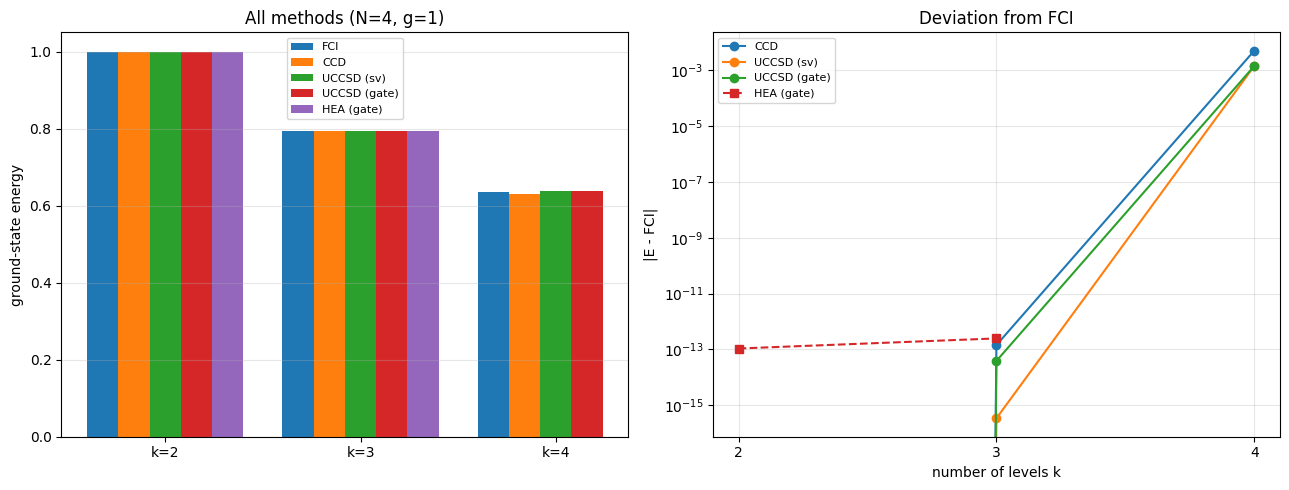

gate-UCCSD and statevector-UCCSD coincide (same unitary); both sit just above FCI.


In [20]:
methods = ['FCI', 'CCD', 'UCCSD (statevector)', 'UCCSD (gate circuit)', 'HEA (gate circuit)']
print(f"{'k':>2} | " + " | ".join(f'{m:>20}' for m in methods))
print("-"*120)
table = {}
for k in (2, 3, 4):
    row = [REF[k]['fci'], REF[k]['ccd'], REF[k]['sv'], gate_res[k], hea_res.get(k, np.nan)]
    table[k] = row
    print(f"{k:>2} | " + " | ".join(f'{v:>20.6f}' if not np.isnan(v) else f"{'(stuck)':>20}" for v in row))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
ks = [2, 3, 4]; x = np.arange(len(ks)); w = 0.16
labels = ['FCI', 'CCD', 'UCCSD (sv)', 'UCCSD (gate)', 'HEA (gate)']
for m, lab in enumerate(labels):
    axL.bar(x + (m-2)*w, [table[k][m] for k in ks], w, label=lab)
axL.set_xticks(x); axL.set_xticklabels([f'k={k}' for k in ks])
axL.set_ylabel('ground-state energy'); axL.set_title('All methods (N=4, g=1)')
axL.legend(fontsize=8); axL.grid(alpha=0.3, axis='y')
for m, lab in zip([1, 2, 3], ['CCD', 'UCCSD (sv)', 'UCCSD (gate)']):
    axR.semilogy(ks, [abs(table[k][m]-table[k][0]) for k in ks], 'o-', label=lab)
hk = [k for k in ks if not np.isnan(table[k][4])]
axR.semilogy(hk, [abs(table[k][4]-table[k][0]) for k in hk], 's--', label='HEA (gate)')
axR.set_xlabel('number of levels k'); axR.set_ylabel('|E - FCI|')
axR.set_title('Deviation from FCI'); axR.legend(fontsize=8); axR.grid(alpha=0.3, which='both'); axR.set_xticks(ks)
plt.tight_layout(); plt.show()
print("gate-UCCSD and statevector-UCCSD coincide (same unitary); both sit just above FCI.")

---
## 15  Resolution refinement: the final state-preparation stage

So far each value of $k$ was solved from scratch.  *Resolution refinement*
(Bogner, Hergert, Hjorth-Jensen, LaRose, Lee, Patkowski, **Phys. Lett. B 875 (2026)
140363**) instead **bootstraps** a high-resolution eigenstate from a low-resolution one,
in three steps:

1. **Prepare** the ground state of a small (low-resolution) model space with any method —
   here the gate-based VQE-UCCSD at $k=2$.
2. **Prolong** that state into the larger (high-resolution) space with an operator $P$
   that lifts each many-body basis state to the *same* basis state, leaving the new
   orbitals empty.
3. **Refine** by adiabatically evolving from the shifted, prolonged low-resolution
   Hamiltonian $P(H_{\rm low}-\mu)P^\dagger$ to the shifted high-resolution Hamiltonian
   $H_{\rm high}-\mu$, with the schedule $\cos^2[\theta(t)]$, $\sin^2[\theta(t)]$,
   $\theta(t)=\pi t/2T$.

The energy shift $\mu$ pushes the tracked low-energy states below zero so they stay
separated from the large null space of $P^\dagger$.  Because the prolongation barely
changes the low-energy structure, the adiabatic time scales only as
$T\sim(\Delta E)^{-1}$ — far better than the generic $(\Delta E_{\min})^{-2}$.

**For the pairing model the resolution is the number of levels $k$** (the size of the
single-particle basis), so this is *basis refinement*: $k=2$ is low resolution and $k=4$
is high resolution, at fixed particle number $N$.  We first demonstrate the full pipeline for $N=2$ (one pair) and $N=4$ (two pairs), then
analyse the **four-particle case in detail up to $k=4$, tracking both the overlap and the
energy**.  The refined high-fidelity state is exactly the
input the **Rodeo algorithm** would then filter to the exact eigenstate — that final
step is *not* implemented here.

### The prolongation operator on a quantum computer

For level (basis) refinement the prolongation is especially simple.  Spin-orbital
$2p+\sigma$ of the low-resolution register ($k_{\rm low}=2$, qubits $0\!-\!3$) maps to the
**same** qubit of the high-resolution register ($k_{\rm high}=4$, qubits $0\!-\!7$); the
new levels $2,3$ (qubits $4\!-\!7$) are initialised to $|0\rangle$:

$$ P\,|\psi_{\rm low}\rangle \;=\; |\psi_{\rm low}\rangle\otimes|0\,0\,0\,0\rangle . $$

On hardware this needs **no gates** beyond running the low-resolution state-preparation
circuit on the low qubits while the new qubits remain in $|0\rangle$.  It is sign-clean
because the new (empty) orbitals sit *after* the occupied ones in the Jordan–Wigner
ordering, so they contribute no parity strings — the canonical-ordering point made in the
paper.  (This is the basis-refinement form of $P$; the paper's Fig. 3 circuit with two
rotations and two CNOTs is the *lattice*-refinement variant, which instead spreads a
density over neighbouring fine sites.)

In [21]:
# ---- low-resolution gate-UCCSD state (k=2) ----
def gate_uccsd_state(k,N,g):
    """Optimize the gate-UCCSD circuit and return (energy, full-space statevector)."""
    su=gate_uccsd_setup(k,N); nq=2*k; dim=2**nq
    H=build_H_full(k,g); terms=su['terms']; gens=su['gens']; hf=su['hf']; P=su['P']
    def state(th):
        psi=np.zeros(dim,complex);psi[hf]=1.0
        for m in range(P): psi=apply_exc_circuit(psi,th[m],terms[m],nq)
        return psi
    def energy(th): psi=state(th);return float(np.real(psi.conj()@(H@psi)))
    def grad(th):
        psi=np.zeros(dim,complex);psi[hf]=1.0;st=[psi.copy()]
        for m in range(P): psi=apply_exc_circuit(psi,th[m],terms[m],nq);st.append(psi.copy())
        Hpsi=H@st[P];gg=np.zeros(P)
        for mu in range(P):
            v=gens[mu]@st[mu+1]
            for m in range(mu+1,P): v=apply_exc_circuit(v,th[m],terms[m],nq)
            gg[mu]=2.0*float(np.real(v.conj()@Hpsi))
        return gg
    if P==0: return energy(np.zeros(0)),state(np.zeros(0))
    res=minimize(energy,np.zeros(P),jac=grad,method='L-BFGS-B',
                 options={'ftol':1e-13,'gtol':1e-11,'maxiter':2000})
    return res.fun,state(res.x)

print("Low-resolution VQE-UCCSD (k=2), used as the first guess")
print("="*60)
low_state={}
for N in (2,4):
    Eg,psi_full=gate_uccsd_state(2,N,1.0)
    nq,states,index=build_sector(2,N); Hl=H_pairing_sparse(2,1.0,N,states,index).toarray()
    w,v=np.linalg.eigh(Hl); El=w[0]
    sec=np.array([psi_full[s] for s in states]); sec=sec/np.linalg.norm(sec)
    ov=abs(np.vdot(v[:,0],sec))**2
    low_state[N]=(El,sec)
    print(f"  N={N}: E_VQE(k=2)={Eg:.6f}  exact E_low={El:.6f}  "
          f"|<exact|VQE>|^2={ov:.6f}  (#params={gate_uccsd_setup(2,N)['P']})")

Low-resolution VQE-UCCSD (k=2), used as the first guess
  N=2: E_VQE(k=2)=-0.618034  exact E_low=-0.618034  |<exact|VQE>|^2=1.000000  (#params=3)
  N=4: E_VQE(k=2)=1.000000  exact E_low=1.000000  |<exact|VQE>|^2=1.000000  (#params=0)


In [22]:
# ---- prolongation operator P (level/basis refinement embedding) ----
def prolong_matrix(k_low,k_high,N):
    nl,sl,il=build_sector(k_low,N); nh,sh,ih=build_sector(k_high,N)
    Pm=np.zeros((len(sh),len(sl)))
    for Il in sl:
        Ih=0
        for j in range(nl):
            if _bit(Il,j,nl): Ih |= 1<<(nh-1-j)   # same qubit, new levels empty
        Pm[ih[Ih],il[Il]]=1.0
    return Pm

print("Prolongation k=2 -> k=4 : first-guess quality")
print("="*60)
refine_data={}
for N in (2,4):
    El,psi_low=low_state[N]
    Pm=prolong_matrix(2,4,N)
    Phi0=Pm@psi_low                                   # prolonged state in k=4 sector
    nq,states,index=build_sector(4,N); Hh=H_pairing_sparse(4,1.0,N,states,index).toarray()
    wh,vh=np.linalg.eigh(Hh); Eh=wh[0]; Psih=vh[:,0]
    Eemb=float(Phi0@Hh@Phi0); ov0=abs(np.vdot(Psih,Phi0))**2
    refine_data[N]=dict(Phi0=Phi0,Hh=Hh,Eh=Eh,Psih=Psih,El=El,Pm=Pm,gap=wh[1]-wh[0])
    print(f"  N={N}: <Phi0|H_high|Phi0>={Eemb:.6f} (=E_low? {abs(Eemb-El)<1e-9})  "
          f"E_high={Eh:.6f}  gap={wh[1]-wh[0]:.4f}")
    print(f"        first-guess overlap |<Psi_high| P psi_low>|^2 = {ov0:.4f}")

Prolongation k=2 -> k=4 : first-guess quality
  N=2: <Phi0|H_high|Phi0>=-0.618034 (=E_low? True)  E_high=-0.779164  gap=1.7792
        first-guess overlap |<Psi_high| P psi_low>|^2 = 0.9628
  N=4: <Phi0|H_high|Phi0>=1.000000 (=E_low? True)  E_high=0.635548  gap=1.8231
        first-guess overlap |<Psi_high| P psi_low>|^2 = 0.8676


/tmp/ipykernel_574/2626030865.py:21: ComplexWarning: Casting complex values to real discards the imaginary part
  Eemb=float(Phi0@Hh@Phi0); ov0=abs(np.vdot(Psih,Phi0))**2


### Adiabatic refinement

We now evolve the prolonged state $|\Phi_0\rangle=P|\psi_{\rm low}\rangle$ under

$$H(s)=\cos^2\!\Big(\tfrac{\pi s}{2}\Big)\,P(H_{\rm low}-\mu)P^\dagger
       +\sin^2\!\Big(\tfrac{\pi s}{2}\Big)\,(H_{\rm high}-\mu),\qquad s=t/T,$$

with $\mu=E_{\rm low}+0.6$ so the tracked state sits $0.6$ below the null space.  Each
step $e^{-iH(s)\,\Delta t}$ would be Trotterised into the same rotation+CNOT
Pauli-exponential gates used above; here we evolve the small fixed-$N$ sector exactly and
record the overlap $|\langle\Psi_{\rm high}|\Phi(T)\rangle|^2$ versus the total time $T$
(the pairing-model analogue of Fig. 1 of the paper); the next subsection also tracks the
physical energy $\langle\Phi(T)|H_{\rm high}|\Phi(T)\rangle$.

adiabatic evolution done in 1.9s


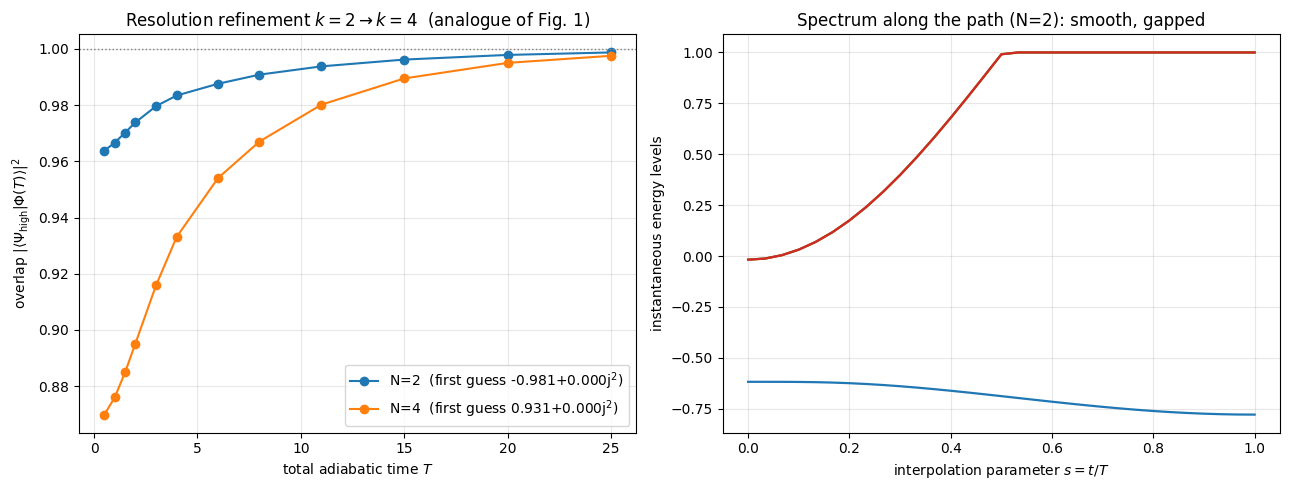

\nFinal overlaps at T=25:  N=2: 0.9988   N=4: 0.9976
The prolonged VQE state is already a high-fidelity guess; adiabatic refinement
drives the overlap toward 1 on a timescale T ~ 1/gap, slower for larger N.


In [23]:
def adiabatic_overlap(N,Ts,M=160,mu_buf=0.6):
    d=refine_data[N]; Hh=d['Hh']; Psih=d['Psih']; El=d['El']; Pm=d['Pm']
    nl,sl,il=build_sector(2,N); Hl=H_pairing_sparse(2,1.0,N,sl,il).toarray()
    mu=El+mu_buf
    Hle=Pm@(Hl-mu*np.eye(len(Hl)))@Pm.T            # P (H_low - mu) P^dagger
    Hhs=Hh-mu*np.eye(len(Hh))                       # H_high - mu
    outs=[]
    for T in Ts:
        psi=d['Phi0'].astype(complex).copy(); dt=T/M
        for m in range(M):
            s=(m+0.5)/M
            Hs=np.cos(np.pi*s/2)**2*Hle+np.sin(np.pi*s/2)**2*Hhs
            psi=expm(-1j*Hs*dt)@psi
        outs.append(abs(np.vdot(Psih,psi))**2)
    return np.array(outs)

# instantaneous spectrum along the path (shows a clean, open gap)
def path_levels(N,nlev=4,ns=31,mu_buf=0.6):
    d=refine_data[N]; Hh=d['Hh']; El=d['El']; Pm=d['Pm']
    nl,sl,il=build_sector(2,N); Hl=H_pairing_sparse(2,1.0,N,sl,il).toarray()
    mu=El+mu_buf; Hle=Pm@(Hl-mu*np.eye(len(Hl)))@Pm.T; Hhs=Hh-mu*np.eye(len(Hh))
    ss=np.linspace(0,1,ns); lev=[]
    for s in ss:
        w=np.linalg.eigvalsh(np.cos(np.pi*s/2)**2*Hle+np.sin(np.pi*s/2)**2*Hhs)
        lev.append(w[:nlev]+mu)
    return ss,np.array(lev)

Ts=np.array([0.5,1,1.5,2,3,4,6,8,11,15,20,25])
t0=time.time()
ov={N:adiabatic_overlap(N,Ts) for N in (2,4)}
print(f"adiabatic evolution done in {time.time()-t0:.1f}s")

fig,(axL,axR)=plt.subplots(1,2,figsize=(13,5))
for N,c in [(2,'C0'),(4,'C1')]:
    axL.plot(Ts,ov[N],c+'o-',label=f'N={N}  (first guess {refine_data[N]["Psih"]@refine_data[N]["Phi0"]:.3f}$^2$)')
axL.axhline(1.0,color='gray',ls=':',lw=1)
axL.set_xlabel('total adiabatic time $T$'); axL.set_ylabel(r'overlap $|\langle\Psi_{\rm high}|\Phi(T)\rangle|^2$')
axL.set_title('Resolution refinement $k=2\\to k=4$  (analogue of Fig. 1)')
axL.legend(); axL.grid(alpha=0.3)

ss,lev=path_levels(2)
for j in range(lev.shape[1]):
    axR.plot(ss,lev[:,j],'-',lw=1.6)
axR.set_xlabel('interpolation parameter $s=t/T$'); axR.set_ylabel('instantaneous energy levels')
axR.set_title('Spectrum along the path (N=2): smooth, gapped')
axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\\nFinal overlaps at T=25:  "+"   ".join(f"N={N}: {ov[N][-1]:.4f}" for N in (2,4)))
print("The prolonged VQE state is already a high-fidelity guess; adiabatic refinement")
print("drives the overlap toward 1 on a timescale T ~ 1/gap, slower for larger N.")

### Four-particle analysis up to $k=4$: overlap *and* energy

We now focus on the four-particle ground state and follow the refinement quantitatively
as the high-resolution space grows from the low-resolution $k=2$ basis up to $k=3$ and
$k=4$.  For each total adiabatic time $T$ we record two quantities of the evolved state
$|\Phi(T)\rangle$:

* the **overlap** $|\langle\Psi_{\rm high}|\Phi(T)\rangle|^2$ with the exact high-resolution
  ground state, and
* the **physical energy** $\langle\Phi(T)|H_{\rm high}|\Phi(T)\rangle$, which is
  variational and therefore approaches the FCI value $E_{\rm FCI}(k)$ from above.

At $N=4$ the low-resolution $k=2$ space is a single (Hartree–Fock) determinant, so the
prolonged state is the $k$-level HF reference; adiabatic refinement then builds in the
pairing correlations, lowering the energy from $E_{\rm HF}=1$ toward the FCI value.

Four-particle resolution refinement (N=4), low resolution k=2
  k=2 -> k=3:  E_low=1.0000   E_FCI(k=3)=0.794697   gap=1.705
     first guess (T->0): overlap=0.9171   energy=1.0000
     refined  (T=30)   : overlap=0.9994   energy=0.796436   (E-E_FCI=+1.7e-03)
  k=2 -> k=4:  E_low=1.0000   E_FCI(k=4)=0.635548   gap=1.823
     first guess (T->0): overlap=0.8676   energy=1.0000
     refined  (T=30)   : overlap=0.9988   energy=0.639654   (E-E_FCI=+4.1e-03)


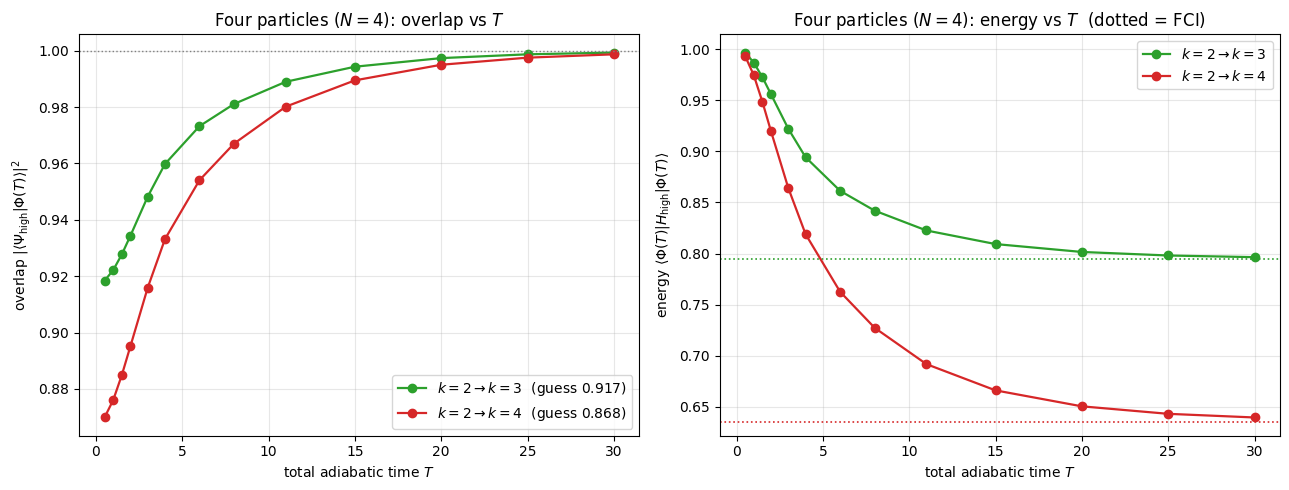


Energy falls from E_HF = 1 toward the FCI value as T grows, while the overlap rises
toward 1; the larger k=4 space starts lower in overlap and converges more slowly.


In [24]:
# ---- four-particle resolution refinement up to k=4: overlap AND energy ----
def refine_NK(N, k_high, Ts, M=160, mu_buf=0.6, g=1.0):
    """Prolong the gate-UCCSD k=2 state into the k_high space and adiabatically refine,
       returning the overlap and the physical energy <H_high> as functions of T."""
    El, psi_low = low_state[N]                          # gate-UCCSD low-resolution (k=2) state
    Pm = prolong_matrix(2, k_high, N); Phi0 = Pm @ psi_low
    nh, sh, ih = build_sector(k_high, N)
    Hh = H_pairing_sparse(k_high, g, N, sh, ih).toarray()
    wh, vh = np.linalg.eigh(Hh); Eh = wh[0]; Psih = vh[:, 0]
    nl, sl, il = build_sector(2, N); Hl = H_pairing_sparse(2, g, N, sl, il).toarray()
    mu = El + mu_buf
    Hle = Pm @ (Hl - mu*np.eye(len(Hl))) @ Pm.T         # P (H_low - mu) P^dagger
    Hhs = Hh - mu*np.eye(len(Hh))                        # H_high - mu
    ov, en = [], []
    for T in Ts:
        psi = Phi0.astype(complex).copy(); dt = T/M
        for m in range(M):
            s = (m+0.5)/M
            Hs = np.cos(np.pi*s/2)**2*Hle + np.sin(np.pi*s/2)**2*Hhs
            psi = expm(-1j*Hs*dt) @ psi
        ov.append(abs(np.vdot(Psih, psi))**2)
        en.append(float(np.real(psi.conj() @ (Hh @ psi))))
    return dict(ov=np.array(ov), en=np.array(en), Eh=Eh, El=El, gap=wh[1]-wh[0],
                ov0=abs(np.vdot(Psih, Phi0))**2, E0=float(np.real(Phi0 @ Hh @ Phi0)))

Ts = np.array([0.5, 1, 1.5, 2, 3, 4, 6, 8, 11, 15, 20, 25, 30])
res44 = {kh: refine_NK(4, kh, Ts) for kh in (3, 4)}

print("Four-particle resolution refinement (N=4), low resolution k=2")
print("="*66)
for kh in (3, 4):
    r = res44[kh]
    print(f"  k=2 -> k={kh}:  E_low={r['El']:.4f}   E_FCI(k={kh})={r['Eh']:.6f}   gap={r['gap']:.3f}")
    print(f"     first guess (T->0): overlap={r['ov0']:.4f}   energy={r['E0']:.4f}")
    print(f"     refined  (T=30)   : overlap={r['ov'][-1]:.4f}   energy={r['en'][-1]:.6f}"
          f"   (E-E_FCI={r['en'][-1]-r['Eh']:+.1e})")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
for kh, c in [(3, 'C2'), (4, 'C3')]:
    r = res44[kh]
    axL.plot(Ts, r['ov'], c+'o-', lw=1.6, label=f'$k=2\\to k={kh}$  (guess {r["ov0"]:.3f})')
    axR.plot(Ts, r['en'], c+'o-', lw=1.6, label=f'$k=2\\to k={kh}$')
    axR.axhline(r['Eh'], color=c, ls=':', lw=1.2)
axL.axhline(1.0, color='gray', ls=':', lw=1)
axL.set_xlabel('total adiabatic time $T$')
axL.set_ylabel(r'overlap $|\langle\Psi_{\rm high}|\Phi(T)\rangle|^2$')
axL.set_title('Four particles ($N=4$): overlap vs $T$'); axL.legend(); axL.grid(alpha=0.3)
axR.set_xlabel('total adiabatic time $T$')
axR.set_ylabel(r'energy $\langle\Phi(T)|H_{\rm high}|\Phi(T)\rangle$')
axR.set_title('Four particles ($N=4$): energy vs $T$  (dotted = FCI)'); axR.legend(); axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("\nEnergy falls from E_HF = 1 toward the FCI value as T grows, while the overlap rises")
print("toward 1; the larger k=4 space starts lower in overlap and converges more slowly.")

### Outlook: the Rodeo algorithm

Resolution refinement turns the cheap low-resolution VQE-UCCSD state into a
high-fidelity approximation of the $k=4$ ground state — already $>0.96$ overlap after
prolongation for $N=2$, and rising toward unity under adiabatic evolution.  Two features
match the paper exactly: the timescale grows only as $(\Delta E)^{-1}$ (the path stays
gapped, right panel), and the larger-$N$ curve starts lower and converges more slowly.

The convergence develops a slow power-law tail at large $T$.  The remedy — the **final
stage of the full pipeline** — is the **Rodeo algorithm**, a stochastic spectral filter
that achieves *exponential* convergence to the exact eigenstate once the input state has
good overlap, exactly the situation produced here.  We implement it in the next section
and feed it the resolution-refined state as input.

---
## 16  Summary

This single notebook now spans the full ladder for the constant-pairing model, from exact
references to a quantum state-preparation pipeline:

* **References (Sections 3–4).** Exact diagonalisation in the seniority-zero pair basis
  (the $6\times6$ `week47.ipynb` matrix at $k=4$), equal to the full $N$-particle FCI, and
  the classical CCD solver — for arbitrary $(k,N)$.

* **Operator-level UCCSD–VQE (Sections 5–9).** The unitary coupled-cluster ansatz as a
  Trotterised product of $2\times2$ Fock-basis rotations: the same solver from $k=2$ to
  $k=8$ (16 qubits) and any even $N$, variational and tracking FCI to
  $\sim\!10^{-3}$–$10^{-2}$ while CCD over-binds.

* **Gate-based VQE (Sections 10–14).** The same ansatz executed as an explicit
  rotation+CNOT circuit: a hardware-efficient ansatz (exact at $k=2$, reaching FCI at
  $k=3$ with restarts, struggling at $k=4$) and a gate-level UCCSD that compiles each
  excitation into CNOT-ladder + $R_z$ circuits, reproduces the operator-level UCCSD
  exactly, and exposes the real hardware cost ($>10^3$ CNOTs at $k=4$).

* **Resolution refinement (Section 15) — the final state-preparation stage.** A cheap
  low-resolution ($k=2$) VQE state is prolonged into the larger space (new levels empty —
  a gate-free embedding for basis refinement) and adiabatically refined to the
  high-resolution ground state.  For four particles up to $k=4$ the overlap with the exact
  state rises toward 1 and the energy falls toward $E_{\rm FCI}$ from above, on a timescale
  set by the gap; the path stays gapped, so refinement is efficient.

**Final observation.** Exact diagonalisation and CCD set the benchmark; the Trotterised UCCSD–VQE
matches them and scales; the gate-based circuits show how that ansatz runs on hardware;
and resolution refinement bootstraps a high-fidelity state across resolutions.  That
refined state is exactly the input for the **Rodeo algorithm**, a stochastic spectral
filter that would converge it exponentially to the exact eigenstate. This is the natural next
step. May be we could use your existing codes Dean? The Rodeo is  **not implemented here**.

These notes build on material from the courses *FYS4480 Many-body Physics* and *FYS5419
Quantum Computing and Quantum ML* (University of Oslo), *Lecture Notes in Physics* 936
(Chapter 8), and the resolution-refinement method of Bogner, Hergert, Hjorth-Jensen,
LaRose, Lee & Patkowski, *Phys. Lett. B* **875** (2026) 140363.

---
## 11&nbsp; The Rodeo algorithm: exponential filtering of the refined state

The resolution-refined state is a high-fidelity approximation of the $k=4$ ground state, but
its overlap with the exact eigenstate saturates below one (the slow tail above).  The
**Rodeo algorithm** (RA) removes the residual error *exponentially fast*, and it is exactly
the algorithm benchmarked in Qian *et al.*, *Eur. Phys. J. A* **60**, 151 (2024).  One RA
cycle (their Fig. 1) acts on the system register plus a single ancilla:

1. Hadamard on the ancilla $|0\rangle\to(|0\rangle+|1\rangle)/\sqrt2$;
2. **controlled** $e^{-iH t_k}$ on the system (control $=$ ancilla);
3. a phase gate $P(E\,t_k)$ on the ancilla (this is what shifts $H\to H-E$);
4. a second Hadamard, then **measure** the ancilla.

Post-selecting the ancilla in $|0\rangle$ applies the (non-unitary) filter
$\tfrac12\big(\mathbb{1}+e^{iE t_k}e^{-iH t_k}\big)$ to the system: on an eigenstate
$|E_j\rangle$ this multiplies the amplitude by $e^{i(E-E_j)t_k/2}\cos\!\big[(E_j-E)t_k/2\big]$.
For an eigenstate input the probability that all $M$ ancilla measurements return $0$ is
therefore
$$
P_{0^M}(E\mid\{t_k\})=\prod_{k=1}^{M}\cos^2\!\Big[\tfrac{t_k}{2}(E_{\rm obj}-E)\Big],
\qquad\text{(paper Eq.\,1)}
$$
and averaging the $t_k$ over a Gaussian of RMS width $\sigma$ gives
$$
P_{0^M}(E)=\Big[\tfrac12\big(1+e^{-(E_{\rm obj}-E)^2\sigma^2/2}\big)\Big]^{M}.
\qquad\text{(paper Eq.\,2)}
$$
The on-resonance peak ($E=E_{\rm obj}$) is exactly $1$ at every cycle, while off-resonant
weight is suppressed geometrically (the background sits near $2^{-M}$).  Scanning $E$ thus
locates eigenvalues as peaks; fixing $E$ at the target eigenvalue turns the RA into a
state-preparation filter whose post-selected fidelity obeys
$1-\mathcal F_M\lesssim\frac{1-p}{p}\,2^{-M}$, with $p$ the input overlap.  Because resolution
refinement already supplies $p\approx1$, only a handful of cycles are needed and the
post-selection acceptance stays of order $p$.

In [25]:
# ---- one rodeo cycle: explicit ancilla circuit, post-selected on ancilla |0> ----
def rodeo_cycle_ancilla(v, U, t, E):
    """Hadamard - controlled-U(t) - phase P(Et) - Hadamard - measure(post-select |0>).
       Joint state stored as (D,2): column a = ancilla |a>.  Returns (state|0>, success prob)."""
    D = len(v); J = np.zeros((D, 2), complex); J[:, 0] = v          # ancilla starts |0>
    a0, a1 = J[:, 0], J[:, 1]
    J = np.stack([(a0 + a1), (a0 - a1)], axis=1) / np.sqrt(2)        # H on ancilla
    J[:, 1] = U @ J[:, 1]                                            # controlled-U (ancilla=1)
    J[:, 1] = J[:, 1] * np.exp(1j * E * t)                           # phase P(Et) on ancilla=1
    a0, a1 = J[:, 0], J[:, 1]
    J = np.stack([(a0 + a1), (a0 - a1)], axis=1) / np.sqrt(2)        # H on ancilla
    w = J[:, 0]; p = float(np.vdot(w, w).real)                       # post-select ancilla |0>
    return w / np.sqrt(p), p

# the same map in compact form: post-selected branch = (I + e^{iEt} U)/2
def rodeo_post0(v, U, t, E):
    w = 0.5 * (v + np.exp(1j * E * t) * (U @ v))
    p = float(np.vdot(w, w).real)
    return w / np.sqrt(p), p

# --- check the two agree, and reproduce paper Eqs. (1)-(2) ---
rng = np.random.default_rng(1)
Hh4 = refine_data[4]['Hh']; wv, Vv = np.linalg.eigh(Hh4)
v_test = rng.normal(size=len(Hh4)) + 1j*rng.normal(size=len(Hh4)); v_test /= np.linalg.norm(v_test)
U_test = expm(-1j*Hh4*0.7)
va, pa = rodeo_cycle_ancilla(v_test.copy(), U_test, 0.7, 0.5)
vb, pb = rodeo_post0(v_test.copy(), U_test, 0.7, 0.5)
print(f"ancilla-circuit vs compact filter:  |dpsi|={np.max(np.abs(va-vb)):.1e}  |dp|={abs(pa-pb):.1e}")

# Eq.(1): eigenstate input -> product of cos^2 ; Eq.(2): Gaussian average
sigma = 3.0; Eobj = wv[0]; psi_eig = Vv[:, 0]                        # ground eigenstate
ts5 = rng.normal(0, sigma, 5)
P_eq1 = 1.0; v = psi_eig.astype(complex)
for t in ts5:
    v, p = rodeo_post0(v, expm(-1j*Hh4*t), t, wv[2]); P_eq1 *= p      # off-resonance E=wv[2]
prod_cos2 = np.prod(np.cos(ts5*(Eobj - wv[2])/2)**2)
print(f"Eq.(1) eigenstate: rodeo all-zero prob={P_eq1:.6f}  prod cos^2={prod_cos2:.6f}")
for dE in (0.0, 0.5, 1.0):
    emp = np.mean(np.cos((dE)*rng.normal(0, sigma, 400000)/2)**2)
    print(f"Eq.(2) dE={dE}: <cos^2> empirical={emp:.4f}  (1+e^-(dE s)^2/2)/2={0.5*(1+np.exp(-dE**2*sigma**2/2)):.4f}")

ancilla-circuit vs compact filter:  |dpsi|=1.1e-16  |dp|=1.7e-16
Eq.(1) eigenstate: rodeo all-zero prob=0.012132  prod cos^2=0.012132
Eq.(2) dE=0.0: <cos^2> empirical=1.0000  (1+e^-(dE s)^2/2)/2=1.0000
Eq.(2) dE=0.5: <cos^2> empirical=0.6629  (1+e^-(dE s)^2/2)/2=0.6623
Eq.(2) dE=1.0: <cos^2> empirical=0.5072  (1+e^-(dE s)^2/2)/2=0.5056


### The input state: the resolution-refined $k=4$ ground state

The state fed to the rodeo filter is exactly the output of the previous section — the
prolonged $k=2$ VQE state, adiabatically refined in the $k=4$ space.  We rebuild it as an
explicit state vector (in the $N=4$, $k=4$ particle sector, on which the rodeo
controlled-evolution acts; on hardware $e^{-iHt}$ is Suzuki--Trotterised over the $2k=8$
qubits).  For contrast we also keep the *un-refined* prolonged guess $\Phi_0$, which has a
lower overlap $p$.

In [26]:
def refine_state(N, k_high, T, M=160, mu_buf=0.6, g=1.0):
    """Return the adiabatically resolution-refined state vector (normalised) and H_high."""
    El, psi_low = low_state[N]
    Pm = prolong_matrix(2, k_high, N); Phi0 = Pm @ psi_low
    nh, sh, ih = build_sector(k_high, N); Hh = H_pairing_sparse(k_high, g, N, sh, ih).toarray()
    nl, sl, il = build_sector(2, N);    Hl = H_pairing_sparse(2, g, N, sl, il).toarray()
    mu = El + mu_buf
    Hle = Pm @ (Hl - mu*np.eye(len(Hl))) @ Pm.T; Hhs = Hh - mu*np.eye(len(Hh))
    psi = Phi0.astype(complex).copy(); dt = T/M
    for m in range(M):
        s = (m + 0.5)/M
        psi = expm(-1j*(np.cos(np.pi*s/2)**2*Hle + np.sin(np.pi*s/2)**2*Hhs)*dt) @ psi
    return psi/np.linalg.norm(psi), Phi0/np.linalg.norm(Phi0), Hh

psi_refined, psi_prolonged, Hrod = refine_state(4, 4, 25.0)
wR, VR = np.linalg.eigh(Hrod); E0 = wR[0]; GS = VR[:, 0]
p_refined   = abs(np.vdot(GS, psi_refined))**2
p_prolonged = abs(np.vdot(GS, psi_prolonged))**2
print(f"target ground-state energy E0 = {E0:.6f}   (gap to 1st excited = {wR[1]-wR[0]:.4f})")
print(f"input overlap p with exact GS:  prolonged Phi0 = {p_prolonged:.5f}"
      f"    resolution-refined (T=25) = {p_refined:.5f}")

target ground-state energy E0 = 0.635548   (gap to 1st excited = 1.8231)
input overlap p with exact GS:  prolonged Phi0 = 0.86764    resolution-refined (T=25) = 0.99757


### Energy scan: locating the eigenvalue (paper Fig. 3 analogue)

Scanning the target energy $E$ and plotting the all-zero success probability $P_{0^M}(E)$
(averaged over random time sets) produces peaks at the eigenvalues.  A coarse scan
($\sigma=2$) resolves the ground state from the excited band; a finer scan ($\sigma=8$)
sharpens the ground-state peak.  Starting from the *prolonged* state, the small residual
weight on excited states is visible as secondary structure; starting from the *refined*
state, essentially all weight sits in the single ground-state peak.

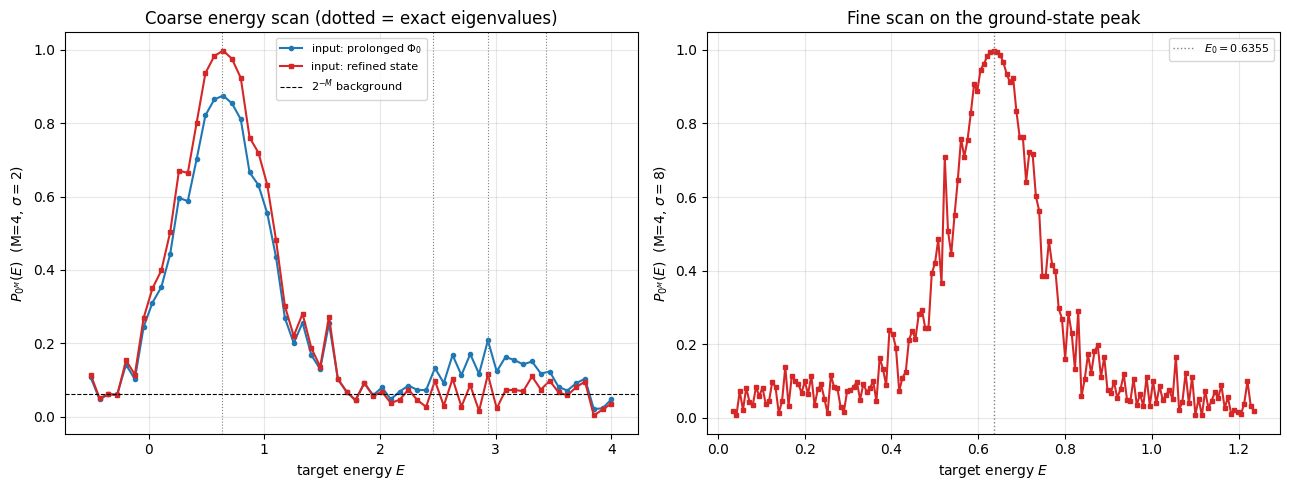

peak of fine scan at E = 0.6352  (exact E0 = 0.635548)


In [27]:
def rodeo_allzero_prob(v0, ts, E, H):
    """Joint probability of the all-zero ancilla string for time set ts at target E."""
    v = v0.astype(complex).copy(); P = 1.0
    for t in ts:
        v, p = rodeo_post0(v, expm(-1j*H*t), t, E); P *= p
    return P

def scan(v0, Es, sigma, H, M=4, n_sets=12, seed=0):
    rng = np.random.default_rng(seed)
    out = np.zeros(len(Es))
    for s in range(n_sets):
        for j, E in enumerate(Es):
            out[j] += rodeo_allzero_prob(v0, rng.normal(0, sigma, M), E, H)
    return out/n_sets

Es_coarse = np.linspace(-0.5, 4.0, 60)
Es_fine   = np.linspace(E0-0.6, E0+0.6, 161)
Pc_pro = scan(psi_prolonged, Es_coarse, 2.0, Hrod)
Pc_ref = scan(psi_refined,   Es_coarse, 2.0, Hrod)
Pf_ref = scan(psi_refined,   Es_fine,   8.0, Hrod)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
axL.plot(Es_coarse, Pc_pro, 'o-', ms=3, color='C0', label='input: prolonged $\\Phi_0$')
axL.plot(Es_coarse, Pc_ref, 's-', ms=3, color='C3', label='input: refined state')
for e in np.unique(np.round(wR[wR < 4.2], 4)):
    axL.axvline(e, color='gray', ls=':', lw=0.8)
axL.axhline(0.5**4, color='k', ls='--', lw=0.8, label='$2^{-M}$ background')
axL.set_xlabel('target energy $E$'); axL.set_ylabel(r'$P_{0^M}(E)$  (M=4, $\sigma=2$)')
axL.set_title('Coarse energy scan (dotted = exact eigenvalues)'); axL.legend(fontsize=8); axL.grid(alpha=0.3)

axR.plot(Es_fine, Pf_ref, 's-', ms=3, color='C3')
axR.axvline(E0, color='gray', ls=':', lw=1.0, label=f'$E_0={E0:.4f}$')
axR.set_xlabel('target energy $E$'); axR.set_ylabel(r'$P_{0^M}(E)$  (M=4, $\sigma=8$)')
axR.set_title('Fine scan on the ground-state peak'); axR.legend(fontsize=8); axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()
jpk = np.argmax(Pf_ref)
if 0 < jpk < len(Es_fine)-1:                       # parabolic refinement of the peak
    y0,y1,y2 = Pf_ref[jpk-1:jpk+2]; dx = Es_fine[1]-Es_fine[0]
    Epk = Es_fine[jpk] + 0.5*dx*(y0-y2)/(y0-2*y1+y2)
else:
    Epk = Es_fine[jpk]
print(f"peak of fine scan at E = {Epk:.4f}  (exact E0 = {E0:.6f})")

### Eigenstate preparation: fidelity and acceptance vs. the number of cycles $M$

Fixing $E=E_0$ and applying $M$ rodeo cycles to the input state, we track the post-selected
fidelity $\mathcal F_M=|\langle\Psi_0|\Phi_M\rangle|^2$ and the cumulative acceptance
probability (all $M$ ancillas read $0$), each averaged over random time sets.  The refined
input ($p\approx0.998$) is already filtered to machine precision within one or two cycles;
even the cruder prolonged input ($p\approx0.87$) reaches $1-\mathcal F\sim10^{-4}$ in a few
cycles.  In both cases the acceptance stays $\approx p$, so the expected number of circuit
repetitions is only $\sim1/p$ — the concrete pay-off of supplying the rodeo with a
high-overlap state.

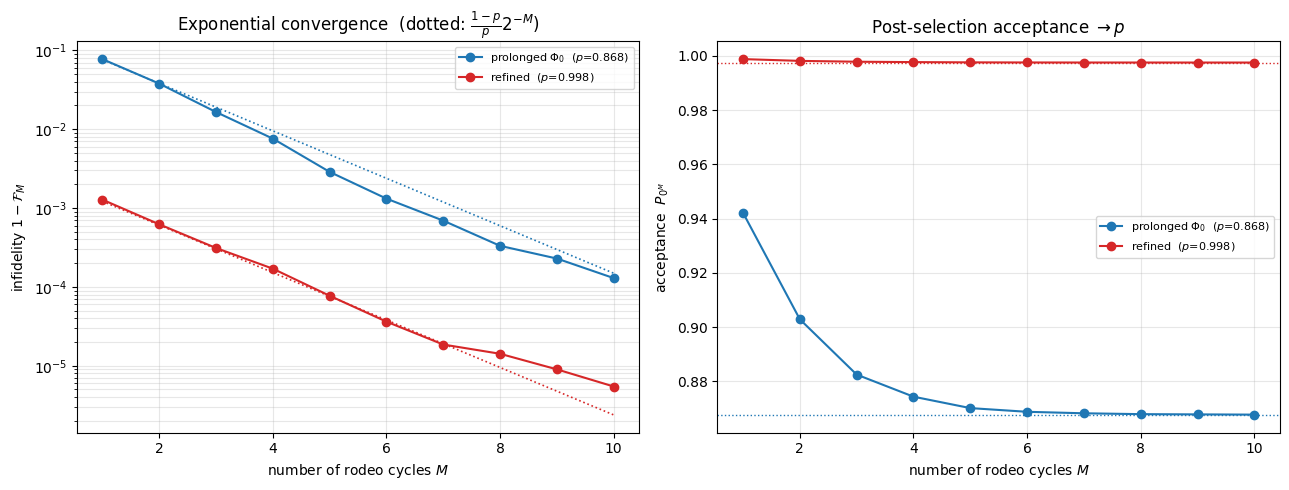

Final fidelities (M = 10, averaged over 40 time sets):
  prolonged $\Phi_0$  ($p$=0.868) : F=0.999871  1-F=1.3e-04  acceptance=0.8677
  refined  ($p$=0.998)            : F=0.999995  1-F=5.5e-06  acceptance=0.9976


In [28]:
def rodeo_track(v0, ts, E, H, GSvec):
    """Run the cycles; return fidelity-with-GS and cumulative acceptance after each cycle."""
    v = v0.astype(complex).copy(); P = 1.0; F, A = [], []
    for t in ts:
        v, p = rodeo_post0(v, expm(-1j*H*t), t, E); P *= p
        F.append(abs(np.vdot(GSvec, v))**2); A.append(P)
    return np.array(F), np.array(A)

M_max, n_sets, sigma = 10, 40, 3.0
rng = np.random.default_rng(7)
inputs = [('prolonged $\\Phi_0$  ($p$=%.3f)' % p_prolonged, psi_prolonged, p_prolonged, 'C0'),
          ('refined  ($p$=%.3f)' % p_refined,   psi_refined,   p_refined,   'C3')]
results = {}
for name, v0, p0, c in inputs:
    F = np.zeros(M_max); A = np.zeros(M_max)
    for s in range(n_sets):
        f, a = rodeo_track(v0, rng.normal(0, sigma, M_max), E0, Hrod, GS)
        F += f; A += a
    results[name] = (F/n_sets, A/n_sets, p0, c)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
Ms = np.arange(1, M_max+1)
for name, (F, A, p0, c) in results.items():
    axL.semilogy(Ms, 1-F, 'o-', color=c, label=name)
    axL.semilogy(Ms, (1-p0)/p0 * 2.0**(-Ms), ':', color=c, lw=1.2)
axL.set_xlabel('number of rodeo cycles $M$'); axL.set_ylabel(r'infidelity $1-\mathcal{F}_M$')
axL.set_title('Exponential convergence  (dotted: $\\frac{1-p}{p}2^{-M}$)')
axL.legend(fontsize=8); axL.grid(alpha=0.3, which='both')
for name, (F, A, p0, c) in results.items():
    axR.plot(Ms, A, 'o-', color=c, label=name)
    axR.axhline(p0, color=c, ls=':', lw=1.0)
axR.set_xlabel('number of rodeo cycles $M$'); axR.set_ylabel('acceptance  $P_{0^M}$')
axR.set_title('Post-selection acceptance $\\to p$'); axR.legend(fontsize=8); axR.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Final fidelities (M = %d, averaged over %d time sets):" % (M_max, n_sets))
for name, (F, A, p0, c) in results.items():
    print(f"  {name:32s}: F={F[-1]:.6f}  1-F={1-F[-1]:.1e}  acceptance={A[-1]:.4f}")

<!-- EXT:TROTTER -->
---
## 13&nbsp; Circuit-level product formulas: Trotterising the whole pipeline

So far the refinement slices and the rodeo's controlled evolution used *exact*
sector exponentials.  On hardware both are product formulas.  We now quantify the
Trotter error at the circuit level, using the term decomposition that matches the
gate compilation of the paper: the diagonal term $D$ (kinetic + $p{=}q$ pairing:
single-qubit phases and $ZZ$ rotations) and one pair-hopping term $h_{pq}$ per
level pair.  Each $e^{-ih_{pq}\,\delta t}$ is realised *exactly* by its eight
commuting weight-4 Pauli rotations, so the only error is the non-commutativity
*between* terms --- exactly as on a device.  We use `pairinglib.pairing_terms`,
`trotter_U`, `refine_state_trotter` and `rodeo_track_U`; nothing is redefined here.


In [29]:
<!-- EXT:TROTTER -->
import numpy as np, matplotlib.pyplot as plt
try:
    import pairinglib as pl
except ModuleNotFoundError:
    import sys, pathlib
    sys.path.insert(0, str((pathlib.Path.cwd()/".."/"src").resolve()))
    import pairinglib as pl

N, G = 4, 1.0
# term decomposition reproduces H exactly, and the Trotter error scales as expected
nq4, st4, ix4 = pl.build_sector(4, N)
H4 = pl.H_pairing_sparse(4, G, N, st4, ix4).toarray()
D4, hops4 = pl.pairing_terms(4, G, N)
print("‖(D + Σ h_pq) − H‖₂  =", np.linalg.norm(D4 + sum(hops4) - H4, 2))
print("\nTrotter error ‖U_trot − e^{−iHt}‖₂ at t = 1, k = 4:")
print(f"{'n_steps':>8} {'order 1':>12} {'order 2':>12}")
for n in (1, 2, 4, 8, 16):
    e1 = pl.trotter_error(4, G, N, 1.0, n, order=1)
    e2 = pl.trotter_error(4, G, N, 1.0, n, order=2)
    print(f"{n:>8} {e1:>12.3e} {e2:>12.3e}")


‖(D + Σ h_pq) − H‖₂  = 0.0

Trotter error ‖U_trot − e^{−iHt}‖₂ at t = 1, k = 4:
 n_steps      order 1      order 2
       1    1.500e+00    9.631e-01
       2    6.474e-01    1.491e-01
       4    3.067e-01    3.400e-02
       8    1.506e-01    8.322e-03
      16    7.475e-02    2.070e-03


circuit-level refined input: n_s=80 (order 2), overlap p = 0.997721
  dt=1.0: infidelity after 6 cycles = 2.887e-01, acceptance = 0.1044
  dt=0.5: infidelity after 6 cycles = 1.700e-03, acceptance = 0.8611
  dt=0.25: infidelity after 6 cycles = 1.217e-04, acceptance = 0.9894
  exact evolution: infidelity = 1.876e-05, acceptance = 0.9977


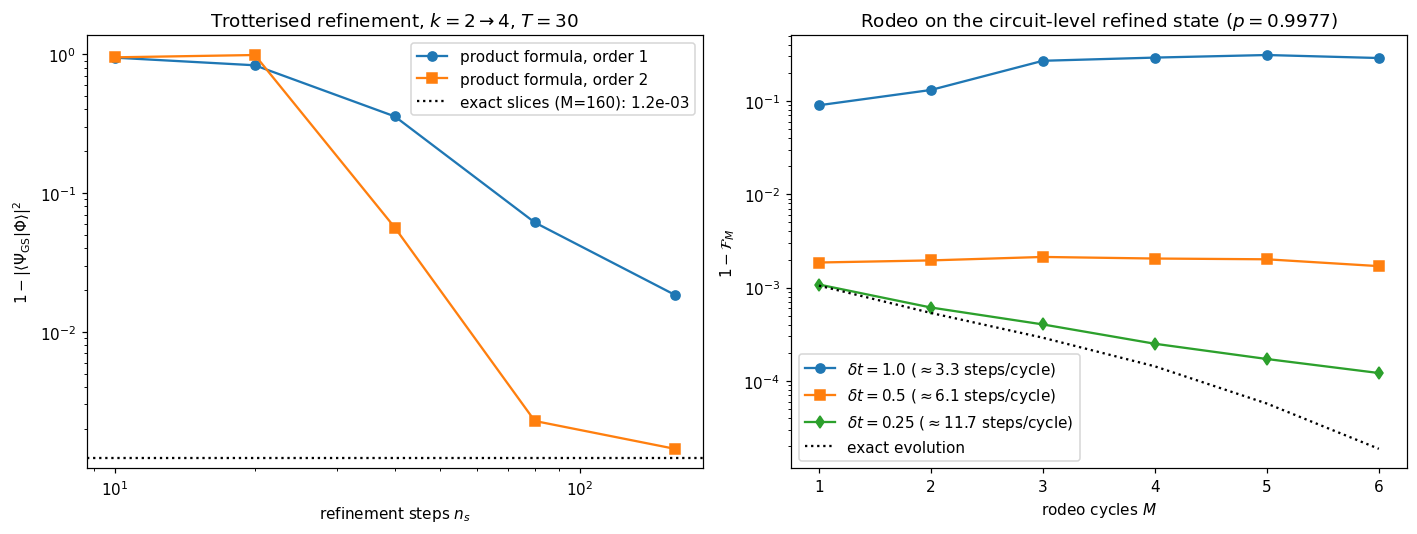

In [30]:
<!-- EXT:TROTTER -->
# ---- circuit-level refinement and rodeo: Trotter error at the pipeline level ----
w4, v4 = np.linalg.eigh(H4); E0 = w4[0]; GS = v4[:, 0]
T_AD = 30.0

# (a) Trotterised refinement k=2->4: infidelity vs number of refinement steps n_s
ns_grid = [10, 20, 40, 80, 160]
inf_ref = {1: [], 2: []}
for order in (1, 2):
    for ns in ns_grid:
        psi, _ = pl.refine_state_trotter(N, 4, T_AD, ns, order=order)
        inf_ref[order].append(1 - abs(np.vdot(GS, psi))**2)
psi_exact_slices, _ = pl.refine_state(N, 4, T_AD)         # exact-slice reference
inf_exact = 1 - abs(np.vdot(GS, psi_exact_slices))**2
p_ref = {o: 1 - np.array(inf_ref[o]) for o in (1, 2)}

# (b) rodeo with a Trotterised controlled evolution at FIXED STEP SIZE dt:
#     a cycle of time t uses ceil(t/dt) steps, as on hardware.
NS_OP = 80                                                 # operating point from (a)
psi_in, _ = pl.refine_state_trotter(N, 4, T_AD, NS_OP, order=2)
p_in = abs(np.vdot(GS, psi_in))**2
terms4 = [D4] + hops4
rng = np.random.default_rng(11)
M_CYC, SIG, NSAMP = 6, 4.0, 12
tsets = [np.abs(rng.normal(0.0, SIG, M_CYC)) for _ in range(NSAMP)]
curves, accepts, mean_steps = {}, {}, {}
for dtm in (1.0, 0.5, 0.25, None):                         # None = exact evolution
    F_acc = np.zeros(M_CYC); A_fin = 0.0; nst = 0
    for ts in tsets:
        if dtm is None:
            F, A = pl.rodeo_track(psi_in, H4, ts, E0, GS)
        else:
            Ufun = lambda t: pl.trotter_U_dt(4, G, N, t, dtm, order=2, terms=terms4)[0]
            F, A = pl.rodeo_track_U(psi_in, Ufun, ts, E0, GS)
            nst += sum(max(1, int(np.ceil(t/dtm))) for t in ts)
        F_acc += F; A_fin += A[-1]
    curves[dtm] = 1 - F_acc/NSAMP
    accepts[dtm] = A_fin/NSAMP
    mean_steps[dtm] = nst/(NSAMP*M_CYC) if dtm else None

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for order, mk in ((1, "o-"), (2, "s-")):
    ax[0].loglog(ns_grid, inf_ref[order], mk, label=f"product formula, order {order}")
ax[0].axhline(inf_exact, ls=":", c="k", label=f"exact slices (M=160): {inf_exact:.1e}")
ax[0].set_xlabel(r"refinement steps $n_s$"); ax[0].set_ylabel(r"$1-|\langle\Psi_{\rm GS}|\Phi\rangle|^2$")
ax[0].set_title(rf"Trotterised refinement, $k=2\to4$, $T={T_AD:.0f}$"); ax[0].legend()
Ms = np.arange(1, M_CYC+1)
for dtm, mk in ((1.0, "o-"), (0.5, "s-"), (0.25, "d-"), (None, "k:")):
    lab = "exact evolution" if dtm is None else rf"$\delta t={dtm}$ ($\approx${mean_steps[dtm]:.1f} steps/cycle)"
    ax[1].semilogy(Ms, curves[dtm], mk, label=lab)
ax[1].set_xlabel(r"rodeo cycles $M$"); ax[1].set_ylabel(r"$1-\mathcal{F}_M$")
ax[1].set_title(rf"Rodeo on the circuit-level refined state ($p={p_in:.4f}$)")
ax[1].legend(); plt.tight_layout(); plt.show()
print(f"circuit-level refined input: n_s={NS_OP} (order 2), overlap p = {p_in:.6f}")
for dtm in (1.0, 0.5, 0.25):
    print(f"  dt={dtm}: infidelity after {M_CYC} cycles = {curves[dtm][-1]:.3e}, acceptance = {accepts[dtm]:.4f}")
print(f"  exact evolution: infidelity = {curves[None][-1]:.3e}, acceptance = {accepts[None]:.4f}")


<!-- EXT:TROTTER -->
### An honest depth budget

The comparison that matters for hardware is **total two-qubit gates per accepted
preparation at matched fidelity**, including the post-selection repetition factor
$1/P_M$.  The VQE's optimisation is a one-time classical cost, after which *every*
preparation replays the full circuit; the pipeline pays its refinement steps on
every repetition instead.  Both totals are computed below from the measured
operating points, with the first-order per-step CNOT counts of the paper
(`pl.cnot_counts`); an order-2 step costs twice the order-1 count.


In [31]:
<!-- EXT:TROTTER -->
# ---- honest depth budget at k=4 (per accepted preparation, matched target) ----
cn = pl.cnot_counts(4)
CN_STEP, CN_CSTEP = cn["step_uncontrolled"], cn["step_controlled"]
ORDER_FAC = 2                                   # order-2 step = 2 x first-order count
E_uccsd, nit = pl.gate_uccsd_vqe(4, N, G, pl.gate_uccsd_setup(4, N))
CN_VQE = 1312
err_vqe = E_uccsd - pl.fci_ground(pl.H_pairing_sparse(4, G, N, st4, ix4))

# pipeline operating point (from the figure above): n_s=80 order-2, dt=0.25, M=2
DT_OP, M_OP = 0.25, 2
Ufun = lambda t: pl.trotter_U_dt(4, G, N, t, DT_OP, order=2, terms=terms4)[0]
rng = np.random.default_rng(3)
F2 = A2 = 0.0; nsteps_tot = 0
for _ in range(NSAMP):
    ts = np.abs(rng.normal(0.0, SIG, M_OP))
    F, A = pl.rodeo_track_U(psi_in, Ufun, ts, E0, GS)
    F2 += F[-1]/NSAMP; A2 += A[-1]/NSAMP
    nsteps_tot += sum(max(1, int(np.ceil(t/DT_OP))) for t in ts)
nsteps_avg = nsteps_tot/NSAMP
cn_refine  = NS_OP * CN_STEP * ORDER_FAC
cn_rodeo   = int(round(nsteps_avg * CN_CSTEP * ORDER_FAC))
cn_run     = cn_refine + cn_rodeo
cn_accept  = cn_run / A2
print("k=4 depth budget (CNOTs), N=4, g=1")
print(f"  UCCSD-VQE preparation:        {CN_VQE} per prep; optimiser: {nit} iterations x (E+grad) evals")
print(f"    variational error:          {err_vqe:.2e}")
print(f"  pipeline (n_s={NS_OP} order-2, M={M_OP} cycles, dt={DT_OP}, sigma={SIG}):")
print(f"    refinement                  {cn_refine}")
print(f"    rodeo cycles (avg {nsteps_avg:.1f} steps) {cn_rodeo}")
print(f"    per run                     {cn_run}")
print(f"    acceptance P_M              {A2:.4f}")
print(f"    per ACCEPTED preparation    {cn_accept:.0f}")
print(f"    final infidelity            {1-F2:.2e}")
print("The pipeline is deeper per accepted shot than one UCCSD replay, but it is")
print("optimiser-free and reaches an infidelity far below the variational floor;")
print("at matched accuracy the variational route has no operating point at all.")


k=4 depth budget (CNOTs), N=4, g=1
  UCCSD-VQE preparation:        1312 per prep; optimiser: 8 iterations x (E+grad) evals
    variational error:          1.44e-03
  pipeline (n_s=80 order-2, M=2 cycles, dt=0.25, sigma=4.0):
    refinement                  47360
    rodeo cycles (avg 27.8 steps) 23157
    per run                     70517
    acceptance P_M              0.9925
    per ACCEPTED preparation    71053
    final infidelity            5.47e-04
The pipeline is deeper per accepted shot than one UCCSD replay, but it is
optimiser-free and reaches an infidelity far below the variational floor;
at matched accuracy the variational route has no operating point at all.


<!-- EXT:TROTTER -->
---
## 14&nbsp; A nontrivial coarse stage: the $k=3\to4$ chain

At $N=4$ the $k=2$ sector is a single determinant, so the coarse "VQE" is gate-free
and the prolonged state is just the Hartree--Fock reference --- the pipeline's first
stage does no work.  Here we start instead from the **gate-level UCCSD state at
$k=3$** (272 CNOTs, and indistinguishable from FCI at this resolution), prolong
$3\to4$, and refine.  The comparison $2\to4$ vs $3\to4$ shows what a better coarse
start buys: a higher initial overlap and a shorter adiabatic stage, at the price of
the coarse-circuit depth.


coarse gate-UCCSD at k=3: E = 0.794697  (FCI 0.794697), 272 CNOTs
prolonged overlap ov0:  2->4: 0.8676   3->4: 0.9637
3->4 reaches overlap>0.99 at T=9.0;  2->4 overlap there: 0.9725


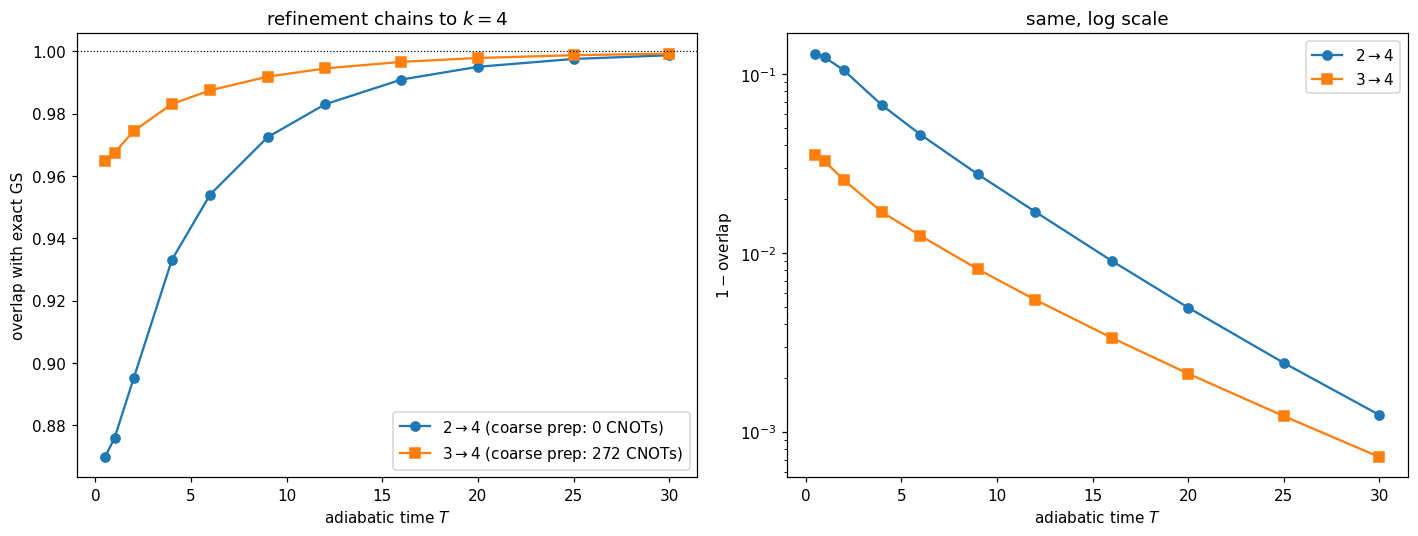

In [35]:
<!-- EXT:TROTTER -->
# ---- k=3->4 chain from the gate-level UCCSD coarse state ----
E3, psi3_full = pl.gate_uccsd_state(3, N, G)
nq3, st3, ix3 = pl.build_sector(3, N)
psi3 = np.array([psi3_full[s] for s in st3])           # project onto the N-sector
psi3 /= np.linalg.norm(psi3)
print(f"coarse gate-UCCSD at k=3: E = {E3:.6f}  (FCI 0.794697), 272 CNOTs")

Ts = np.array([0.5, 1, 2, 4, 6, 9, 12, 16, 20, 25, 30])
r24 = pl.refine_NK(N, 4, Ts, k_low=2)
r34 = pl.refine_from_state(psi3, N, 3, 4, Ts)
print(f"prolonged overlap ov0:  2->4: {r24['ov0']:.4f}   3->4: {r34['ov0']:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(Ts, r24["ov"], "o-", label=r"$2\to4$ (coarse prep: 0 CNOTs)")
ax[0].plot(Ts, r34["ov"], "s-", label=r"$3\to4$ (coarse prep: 272 CNOTs)")
ax[0].axhline(1.0, ls=":", c="k", lw=0.8)
ax[0].set_xlabel(r"adiabatic time $T$"); ax[0].set_ylabel("overlap with exact GS")
ax[0].set_title("refinement chains to $k=4$"); ax[0].legend()
ax[1].semilogy(Ts, 1-r24["ov"], "o-", label=r"$2\to4$")
ax[1].semilogy(Ts, 1-r34["ov"], "s-", label=r"$3\to4$")
ax[1].set_xlabel(r"adiabatic time $T$"); ax[1].set_ylabel(r"$1-$overlap")
ax[1].set_title("same, log scale"); ax[1].legend()
plt.tight_layout(); plt.show()
for i, T in enumerate(Ts):
    if r34["ov"][i] > 0.99:
        print(f"3->4 reaches overlap>0.99 at T={T};  2->4 overlap there: {r24['ov'][i]:.4f}")
        break


<!-- EXT:TROTTER -->
---
## 15&nbsp; Coupling-strength scan and the path gap: testing $T^{*} \sim 1/\Delta E$

All results so far sit at $g=1$.  Two independent knobs probe the robustness of the
refinement.  First we scan the pairing strength from weak ($g=0.3$) to strong
($g=4$) coupling at fixed shift buffer.  The minimum instantaneous gap along the
path turns out to be set by the shift itself, $\Delta E_{\min}\simeq\mu-E_{\rm low}$,
and stays open at every $g$; the required time $T^{*}$ (overlap $\geq 0.99$) grows
with $g$ because the prolonged state starts further from the target (smaller
$\mathrm{ov}_0$), i.e.\ more state rearrangement must fit through the same gap.
Second --- since the gap is controlled by the shift --- we vary $\mu$ directly at
$g=1$ and extract $T^{*}$ against $1/\Delta E_{\min}$: this is the clean test of the
$T\sim1/\Delta E$ scaling, and doubles as the sensitivity study for the (otherwise
ad hoc) choice $\mu=E_{\rm low}+0.6$.


g= 0.3  ov0=0.9895  min path gap=0.600  T*=1.0
g= 0.5  ov0=0.9686  min path gap=0.600  T*=6.0
g= 1.0  ov0=0.8676  min path gap=0.600  T*=16.0
g= 1.5  ov0=0.7344  min path gap=0.600  T*=26.0
g= 2.0  ov0=0.6167  min path gap=0.600  T*=32.0
g= 3.0  ov0=0.4636  min path gap=0.589  T*=50.0
g= 4.0  ov0=0.3810  min path gap=0.568  T*=65.0
mu_buf=0.15  min path gap=0.150  T*=nan
mu_buf=0.30  min path gap=0.300  T*=50.0
mu_buf=0.60  min path gap=0.600  T*=16.0
mu_buf=1.00  min path gap=1.000  T*=8.0
mu_buf=1.50  min path gap=1.499  T*=6.0


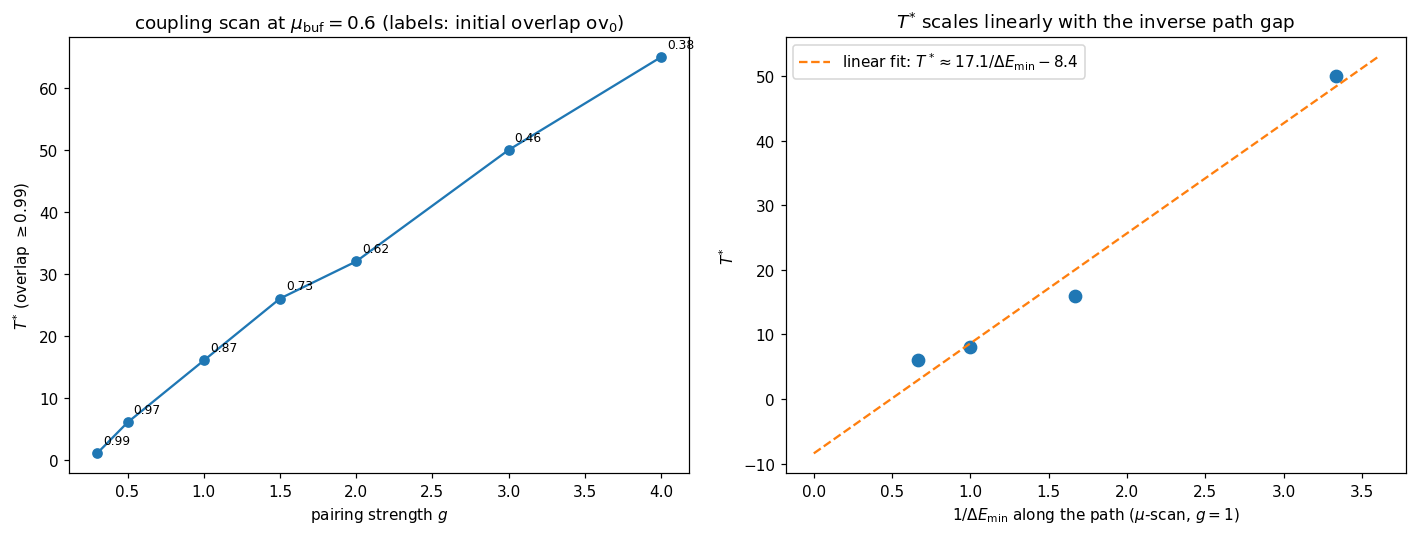

In [36]:
<!-- EXT:TROTTER -->
# ---- (a) g-scan of the k=2->4 refinement at fixed mu_buf=0.6 ----
def min_path_gap(g, mu_buf, k_low=2, k_high=4):
    nl, sl, il = pl.build_sector(k_low, N)
    Hl = pl.H_pairing_sparse(k_low, g, N, sl, il).toarray()
    El = np.linalg.eigvalsh(Hl)[0]
    Pm = pl.prolong_matrix(k_low, k_high, N)
    nh, sh, ih = pl.build_sector(k_high, N)
    Hh = pl.H_pairing_sparse(k_high, g, N, sh, ih).toarray()
    mu = El + mu_buf
    Hle = Pm @ (Hl - mu*np.eye(len(Hl))) @ Pm.T
    Hhs = Hh - mu*np.eye(len(Hh))
    return min(np.diff(np.linalg.eigvalsh(
        np.cos(np.pi*s/2)**2*Hle + np.sin(np.pi*s/2)**2*Hhs)[:2])[0]
        for s in np.linspace(0, 1, 41))

def Tstar_of(r, Ts, target=0.99):
    hit = np.where(r["ov"] >= target)[0]
    return Ts[hit[0]] if hit.size else np.nan

gs_list = [0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
Ts = np.array([0.5, 1, 2, 3, 4, 6, 8, 12, 16, 20, 26, 32, 40, 50, 65, 80])
Tstar_g, gap_g, ov0_g = [], [], []
for g in gs_list:
    r = pl.refine_NK(N, 4, Ts, g=g)
    Tstar_g.append(Tstar_of(r, Ts)); gap_g.append(min_path_gap(g, 0.6)); ov0_g.append(r["ov0"])
    print(f"g={g:4.1f}  ov0={r['ov0']:.4f}  min path gap={gap_g[-1]:.3f}  T*={Tstar_g[-1]}")

# ---- (b) mu-scan at g=1: T* against the inverse path gap ----
mubufs = [0.15, 0.3, 0.6, 1.0, 1.5]
Tstar_mu, gap_mu = [], []
for mb in mubufs:
    r = pl.refine_NK(N, 4, Ts, mu_buf=mb)
    Tstar_mu.append(Tstar_of(r, Ts)); gap_mu.append(min_path_gap(1.0, mb))
    print(f"mu_buf={mb:4.2f}  min path gap={gap_mu[-1]:.3f}  T*={Tstar_mu[-1]}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(gs_list, Tstar_g, "o-", label=r"$T^{*}$")
for g, T, o in zip(gs_list, Tstar_g, ov0_g):
    ax[0].annotate(f"{o:.2f}", (g, T), textcoords="offset points", xytext=(4, 6), fontsize=8)
ax[0].set_xlabel(r"pairing strength $g$"); ax[0].set_ylabel(r"$T^{*}$ (overlap $\geq 0.99$)")
ax[0].set_title(r"coupling scan at $\mu_{\rm buf}=0.6$ (labels: initial overlap ov$_0$)")
x = 1/np.array(gap_mu); y = np.array(Tstar_mu); sel = ~np.isnan(y)
c = np.polyfit(x[sel], y[sel], 1)
xs = np.linspace(0, x[sel].max()*1.08, 50)
ax[1].plot(x, y, "o", ms=8)
ax[1].plot(xs, np.polyval(c, xs), "--",
           label=rf"linear fit: $T^*\approx{c[0]:.1f}/\Delta E_{{\min}}{c[1]:+.1f}$")
ax[1].set_xlabel(r"$1/\Delta E_{\min}$ along the path ($\mu$-scan, $g=1$)")
ax[1].set_ylabel(r"$T^{*}$")
ax[1].set_title(r"$T^{*}$ scales linearly with the inverse path gap")
ax[1].legend()
plt.tight_layout(); plt.show()


## 16&nbsp; Summary: the complete EIGEN-Q pipeline on the pairing model

This notebook now realises the full hybrid pipeline end-to-end on the constant-pairing
Hamiltonian:

1. **Coarse VQE** — a gate-level UCCSD circuit prepares the $k=2$ ground state cheaply
   ($p$ not yet limited by barren plateaus).
2. **Prolongation** — the state is embedded gate-free into the larger $k=4$ space, giving a
   first guess with overlap $\sim0.87$ ($N=4$).
3. **Resolution refinement** — adiabatic evolution along the gapped path
   $\cos^2 P(H_{\rm low}{-}\mu)P^\dagger+\sin^2(H_{\rm high}{-}\mu)$ raises the overlap toward
   one, with $T\sim1/\Delta E$.
4. **Rodeo filtering** — the refined state is polished to machine-precision fidelity in a
   handful of cycles, with the infidelity falling as $\tfrac{1-p}{p}2^{-M}$ and the
   acceptance holding at $\approx p$.

The two algorithms are complementary exactly as argued in the EIGEN-Q proposal: resolution
refinement supplies the large overlap $p\approx1$ that the rodeo algorithm needs to converge
exponentially, while the rodeo algorithm removes the slow adiabatic tail that refinement
alone leaves behind.  The next physical step — Trotterising $e^{-iHt}$ over the $2k$ qubits
and running on hardware (e.g. Magne) — changes only the implementation of the controlled
evolution, not the structure demonstrated here.